# 0.0 Imports

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection
import xgboost as xgb
import catboost as cat

from sklearn import metrics as mt
from matplotlib import pyplot as plt
from IPython.display    import HTML
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_validate, TunedThresholdClassifierCV, StratifiedKFold
from sklearn            import ensemble             as en
from sklearn            import linear_model         as lm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

## 0.1 Helper Functions

In [ ]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

def drop_columns(X, cols=None):
    if cols is None:
        return X
    return X.drop(columns=cols)

## 0.2 Loading Data

In [3]:
df_raw = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv', low_memory=False)

In [4]:
df_raw.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
856858,41,CASH_OUT,453020.32,C1989552898,6491.0,0.0,C935387744,0.0,453020.32,0,0


# 1.0 Descrição dos dados

In [5]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [6]:
df1.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
cols_old = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map (snakecase, cols_old))


df1.columns = cols_new

## 1.2 Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Columns: {}'.format(df1.shape[1]))

Number of Rows: 6362620
Number of Columns: 11


## 1.3 Data Types

In [9]:
df1.dtypes

step                  int64
type                 object
amount              float64
name_orig            object
oldbalance_org      float64
newbalance_orig     float64
name_dest            object
oldbalance_dest     float64
newbalance_dest     float64
is_fraud              int64
is_flagged_fraud      int64
dtype: object

## 1.4 Check NA

In [10]:
df1.isna().sum()

step                0
type                0
amount              0
name_orig           0
oldbalance_org      0
newbalance_orig     0
name_dest           0
oldbalance_dest     0
newbalance_dest     0
is_fraud            0
is_flagged_fraud    0
dtype: int64

## 1.5 Descriptive Statistical

In [11]:
# profile = ProfileReport(df1)
# profile.to_file('../reports/raw_data_report.html')

In [12]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

In [13]:
cat_attributes.sample(5)

,type,name_orig,name_dest
6016532,PAYMENT,C740066086,M969033670
5251354,CASH_OUT,C609890873,C1726846972
3062718,PAYMENT,C1153465205,M1252109349
2465797,PAYMENT,C944656743,M1177121647
2703004,CASH_OUT,C1091402227,C1207423003


### 1.5.1 Numerical Attributes

In [14]:
# Central Tendency - mean, median

ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis

d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(min)).T
d3 = pd.DataFrame (num_attributes.apply(max)).T
d4= pd.DataFrame (num_attributes.apply(lambda x: x.max() - x.min())).T
d5= pd.DataFrame (num_attributes.apply(lambda x: x.skew())).T
d6= pd.DataFrame (num_attributes.apply(lambda x: x.kurtosis())).T

# concatenate
m = pd.concat([d2 ,d3 ,d4 , ct1 ,ct2 , d1 , d5 , d6]).T.reset_index()
m. columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis' ]

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,step,1.0,7.430000e+02,7.420000e+02,2.433972e+02,239.000,1.423320e+02,0.375177,0.329071
1,amount,0.0,9.244552e+07,9.244552e+07,1.798619e+05,74871.940,6.038582e+05,30.993949,1797.956705
2,oldbalance_org,0.0,5.958504e+07,5.958504e+07,8.338831e+05,14208.000,2.888242e+06,5.249136,32.964879
3,newbalance_orig,0.0,4.958504e+07,4.958504e+07,8.551137e+05,0.000,2.924048e+06,5.176884,32.066985
4,oldbalance_dest,0.0,3.560159e+08,3.560159e+08,1.100702e+06,132705.665,3.399180e+06,19.921758,948.674125
5,newbalance_dest,0.0,3.561793e+08,3.561793e+08,1.224996e+06,214661.440,3.674129e+06,19.352302,862.156508
6,is_fraud,0.0,1.000000e+00,1.000000e+00,1.290820e-03,0.000,3.590479e-02,27.779538,769.702982
7,is_flagged_fraud,0.0,1.000000e+00,1.000000e+00,2.514687e-06,0.000,1.585775e-03,630.603629,397659.062500


### 1.5.2 Categorical Attributes

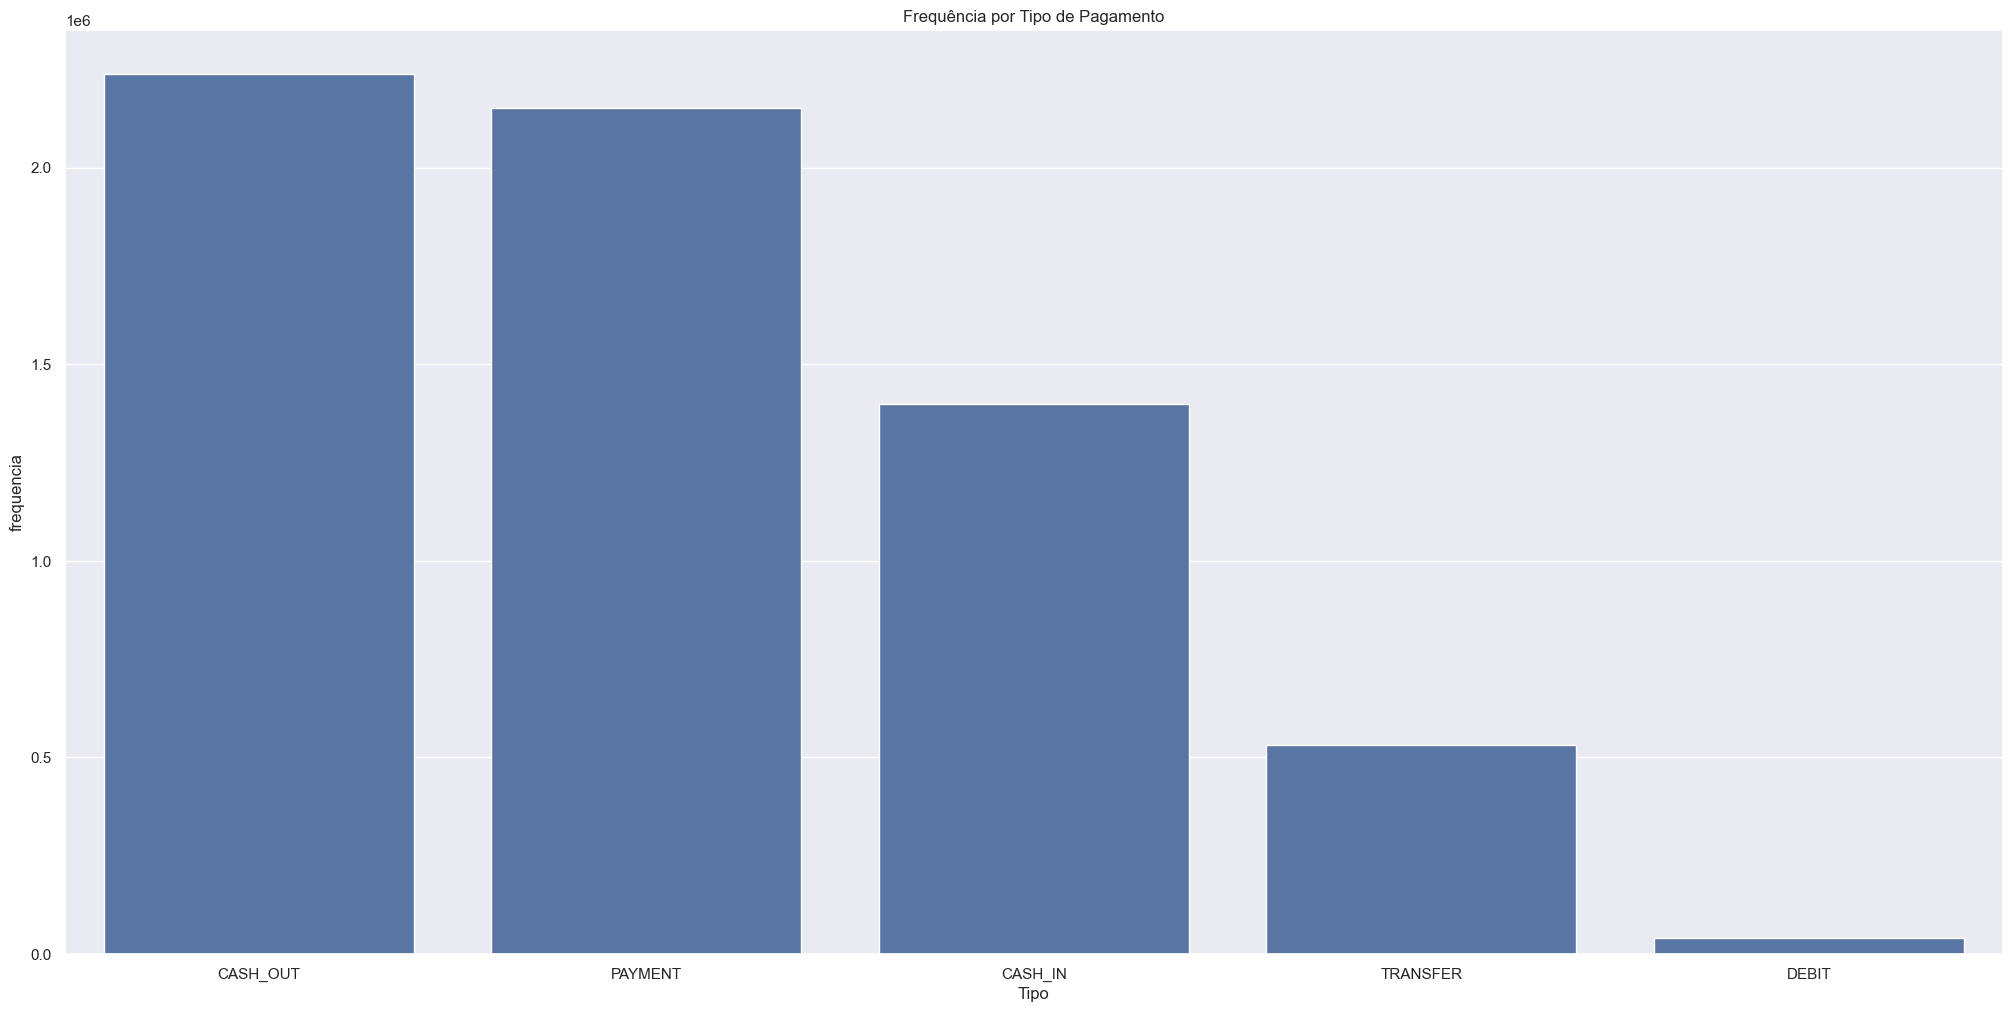

In [15]:
contagem = df1['type'].value_counts().reset_index()
contagem.columns = ['Tipo', 'frequencia']

# Gráfico de barras
sns.barplot(data=contagem, x='Tipo', y='frequencia')
plt.title('Frequência por Tipo de Pagamento')
plt.show()

# 2.0 Feature Engineering

In [16]:
df2 = df1.copy()

In [17]:
def period(h):
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 18:
        return 'Afternoon'
    elif 18 <= h < 24:
        return 'Evening'
    else:
        return 'Night'

In [18]:
# dia

df2['day'] = (df2['step'] // 24) + 1

# hora 

df2['hora'] = df2['step'] % 24

# periodo do dia

df2['period_of_day'] = df2['hora'].apply(period)

In [19]:
df_aux_fraud1 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Morning')]
df_aux_fraud2 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Afternoon')]
df_aux_fraud3 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Evening')]
df_aux_fraud4 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Night')]

In [20]:
print(f"Fraudes no periodo da manha: {df_aux_fraud1.shape[0]}")
print(f"Fraudes no periodo da tarde: {df_aux_fraud2.shape[0]}")
print(f"Fraudes no periodo da noite: {df_aux_fraud3.shape[0]}")
print(f"Fraudes no periodo da madrugada: {df_aux_fraud4.shape[0]}")

Fraudes no periodo da manha: 2460
Fraudes no periodo da tarde: 2077
Fraudes no periodo da noite: 2046
Fraudes no periodo da madrugada: 1630


# 3.0 Filtragem de Variáveis

In [21]:
df3 = df2.copy()

In [22]:
df3.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
4818630,346,CASH_OUT,110248.51,C659149014,0.0,0.0,C1484687714,193505.42,303753.93,0,0,15,10,Morning
1215897,133,PAYMENT,282.03,C1828471095,0.0,0.0,M595477254,0.00,0.00,0,0,6,13,Afternoon
3610033,265,TRANSFER,455299.72,C325282025,0.0,0.0,C1923040679,677041.11,1132340.83,0,0,12,1,Night
1212540,133,TRANSFER,1755121.25,C730239244,0.0,0.0,C371917971,3116529.60,4871650.85,0,0,6,13,Afternoon
6021875,469,CASH_OUT,268032.50,C858995628,49401.0,0.0,C728708407,66497.01,334529.51,0,0,20,13,Afternoon


In [23]:
# Não existe nenhum cliente de origem do tipo Merchant
df_aux2 = df3[df3['name_dest'].str.contains(r'^M', na=False)]

In [24]:
# Não existe nenhuma transição de Merchant classificada como fraude
df_aux2[df_aux2['is_fraud'] == 1].shape

(0, 14)

In [25]:
df_aux = df3[df3['amount'] > 9000000]

In [26]:
df_aux.shape

(6335, 14)

In [27]:
df3_filtered = df3[(~df3['name_dest'].str.contains(r'^M', na=False)) & (df3['amount'] <= 8999999) ]

In [28]:
df3_filtered.shape

(4204790, 14)

In [29]:
num_attributes = df3_filtered.select_dtypes( include=['int64', 'float64'])
cat_attributes = df3_filtered.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

# 4.0 Análise Exploratória de Dados

In [30]:
df4 = df3_filtered.copy()

## 4.1 Análise Univariada

### 4.1.1 Response Variable

In [31]:
df_valid = df4[df4['is_fraud'] == 0]
df_fraud = df4[df4['is_fraud'] == 1]
df_flagged_fraud = df4[df4['is_flagged_fraud'] == 1] 


print(f'Quantidade de transações válidas: {df_valid.shape[0]}')
print(f'Quantidade de transações fraudulentas: {df_fraud.shape[0]}')
print(f'Quantidade de transações com flag de fraudulentas: {df_flagged_fraud.shape[0]}')

Quantidade de transações válidas: 4196921
Quantidade de transações fraudulentas: 7869
Quantidade de transações com flag de fraudulentas: 12


In [32]:
df_fraud['amount'].max()

np.float64(8994286.69)

In [33]:
df_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2348202,189,TRANSFER,2216703.82,C1080269027,2216703.82,0.0,C967600004,0.00,0.00,1,0,8,21,Evening
5988000,413,CASH_OUT,438983.45,C1890267069,438983.45,0.0,C254366528,26861.84,465845.29,1,0,18,5,Morning
6259954,605,TRANSFER,2011285.35,C11988213,2011285.35,0.0,C952860691,0.00,0.00,1,0,26,5,Morning
2115683,183,TRANSFER,342675.47,C1778106585,342675.47,0.0,C144558690,0.00,0.00,1,0,8,15,Afternoon
1068006,120,TRANSFER,377919.58,C1265971736,377919.58,0.0,C806590394,0.00,0.00,1,0,6,0,Night
4023010,299,CASH_OUT,1158358.08,C740548252,1158358.08,0.0,C1317682776,0.00,1158358.08,1,0,13,11,Morning
1937921,177,TRANSFER,586718.88,C153745102,586718.88,0.0,C1921197760,0.00,0.00,1,0,8,9,Morning
3192183,241,TRANSFER,325470.07,C980546604,325470.07,0.0,C1230677699,0.00,0.00,1,0,11,1,Night
6175133,564,CASH_OUT,320977.49,C987967282,320977.49,0.0,C94618150,0.00,320977.49,1,0,24,12,Afternoon
6353620,706,CASH_OUT,265961.00,C1978041486,265961.00,0.0,C1543581230,9354076.45,9620037.45,1,0,30,10,Morning


In [34]:
# Para ter uma flag de fraud é quando a transação é maior que 200k
df_flagged_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6296014,671,TRANSFER,3441041.46,C917414431,3441041.46,3441041.46,C1082139865,0.0,0.0,1,1,28,23,Evening
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1,25,10,Morning
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1,9,20,Evening
6351225,702,TRANSFER,3171085.59,C1892216157,3171085.59,3171085.59,C1308068787,0.0,0.0,1,1,30,6,Morning
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1,11,10,Morning
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1,26,17,Afternoon
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1,17,3,Night
6281484,646,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.0,0.0,1,1,27,22,Evening
6362462,730,TRANSFER,7316255.05,C1869569059,17316255.05,17316255.05,C1861208726,0.0,0.0,1,1,31,10,Morning
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1,12,15,Afternoon


In [35]:
df_test = df4[df4['amount'] >= 200000]

In [36]:
df_test.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2777787,214,CASH_OUT,448071.14,C1189136902,0.0,0.00,C1743463266,925781.60,1373852.73,0,0,9,22,Evening
4799432,345,CASH_OUT,209969.83,C1073750450,19012.0,0.00,C133841926,0.00,209969.83,0,0,15,9,Morning
5561754,385,CASH_OUT,328706.99,C1447068005,0.0,0.00,C1964375014,1448204.23,1776911.22,0,0,17,1,Night
3619809,274,CASH_IN,253537.02,C1408988281,2004.0,255541.02,C1873366993,0.00,0.00,0,0,12,10,Morning
2095888,182,CASH_IN,324779.71,C2109487486,115996.0,440775.71,C1159879037,841911.76,517132.05,0,0,8,14,Afternoon


### 4.1.2 Numerical Attributes

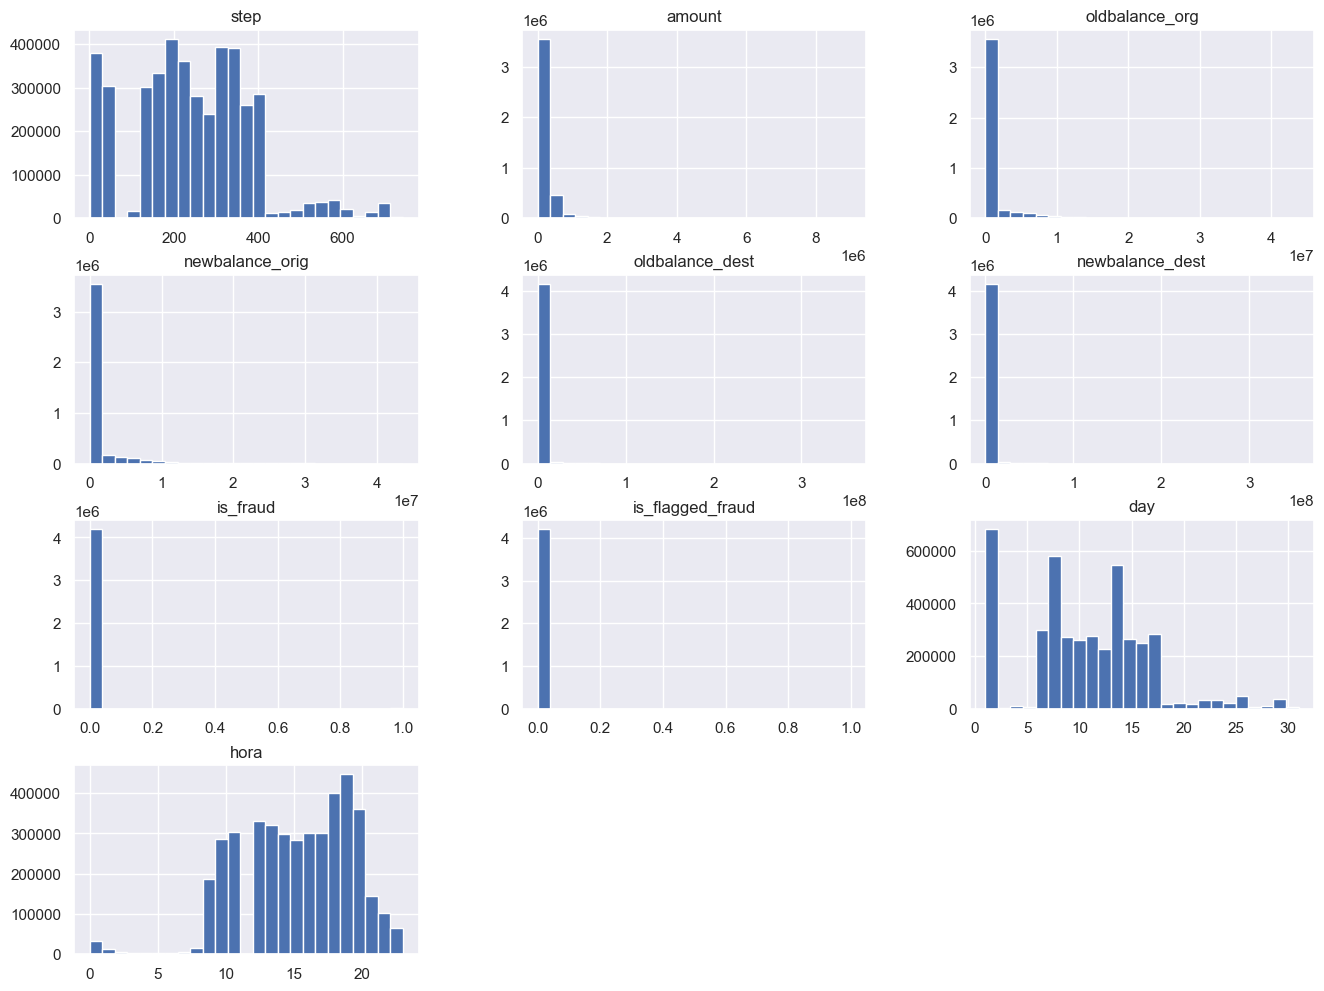

In [37]:
num_attributes.hist(bins= 25, figsize=(16,12));

### 4.1.2 Categorical Variables

<Axes: xlabel='count', ylabel='type'>

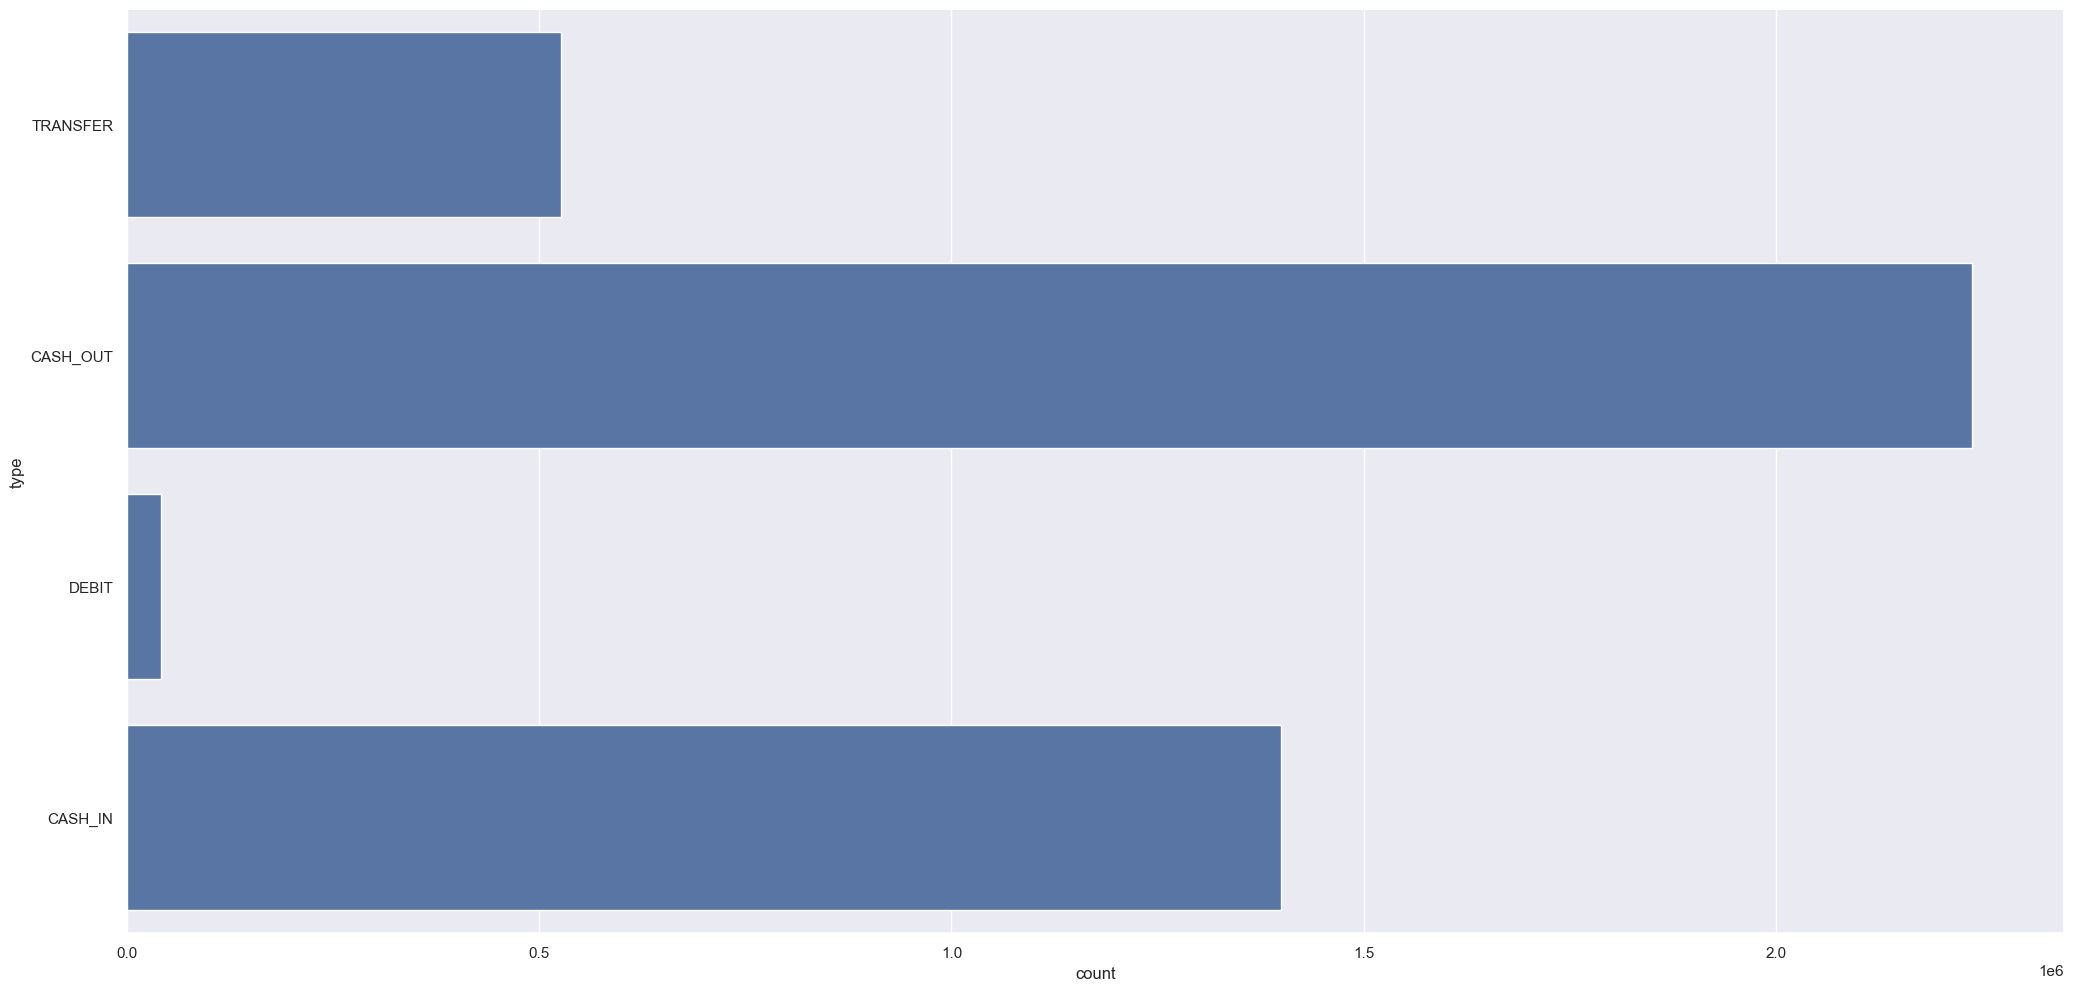

In [38]:
sns.countplot (df4['type'])

## 4.2 Analise Bivariada

In [39]:
df4.columns

Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud', 'day', 'hora', 'period_of_day'],
      dtype='object')

<Axes: xlabel='type', ylabel='is_fraud'>

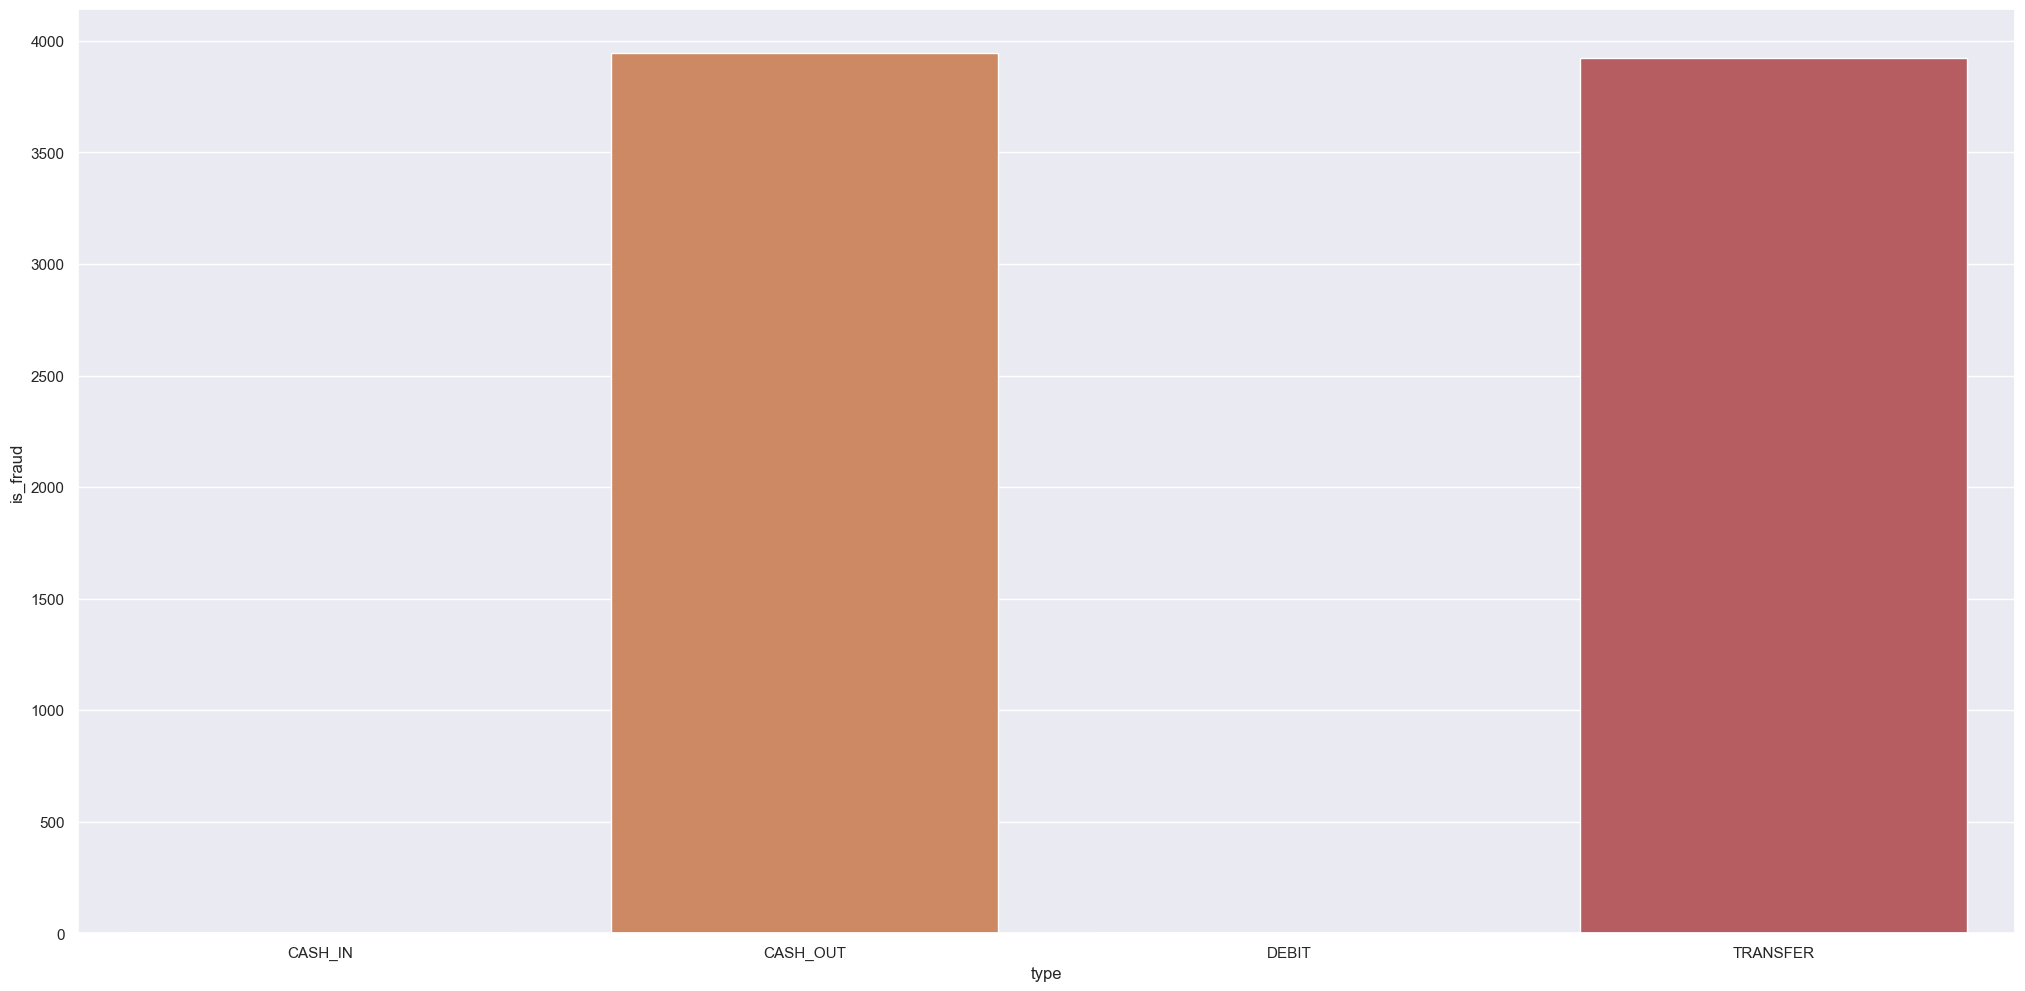

In [40]:
# Tipos de Transações que mais são fraudes

aux1 = df4[['type', 'is_fraud']].groupby('type').sum().reset_index()

sns.barplot( x='type', y='is_fraud', data=aux1, hue='type')

<Axes: xlabel='period_of_day', ylabel='is_fraud'>

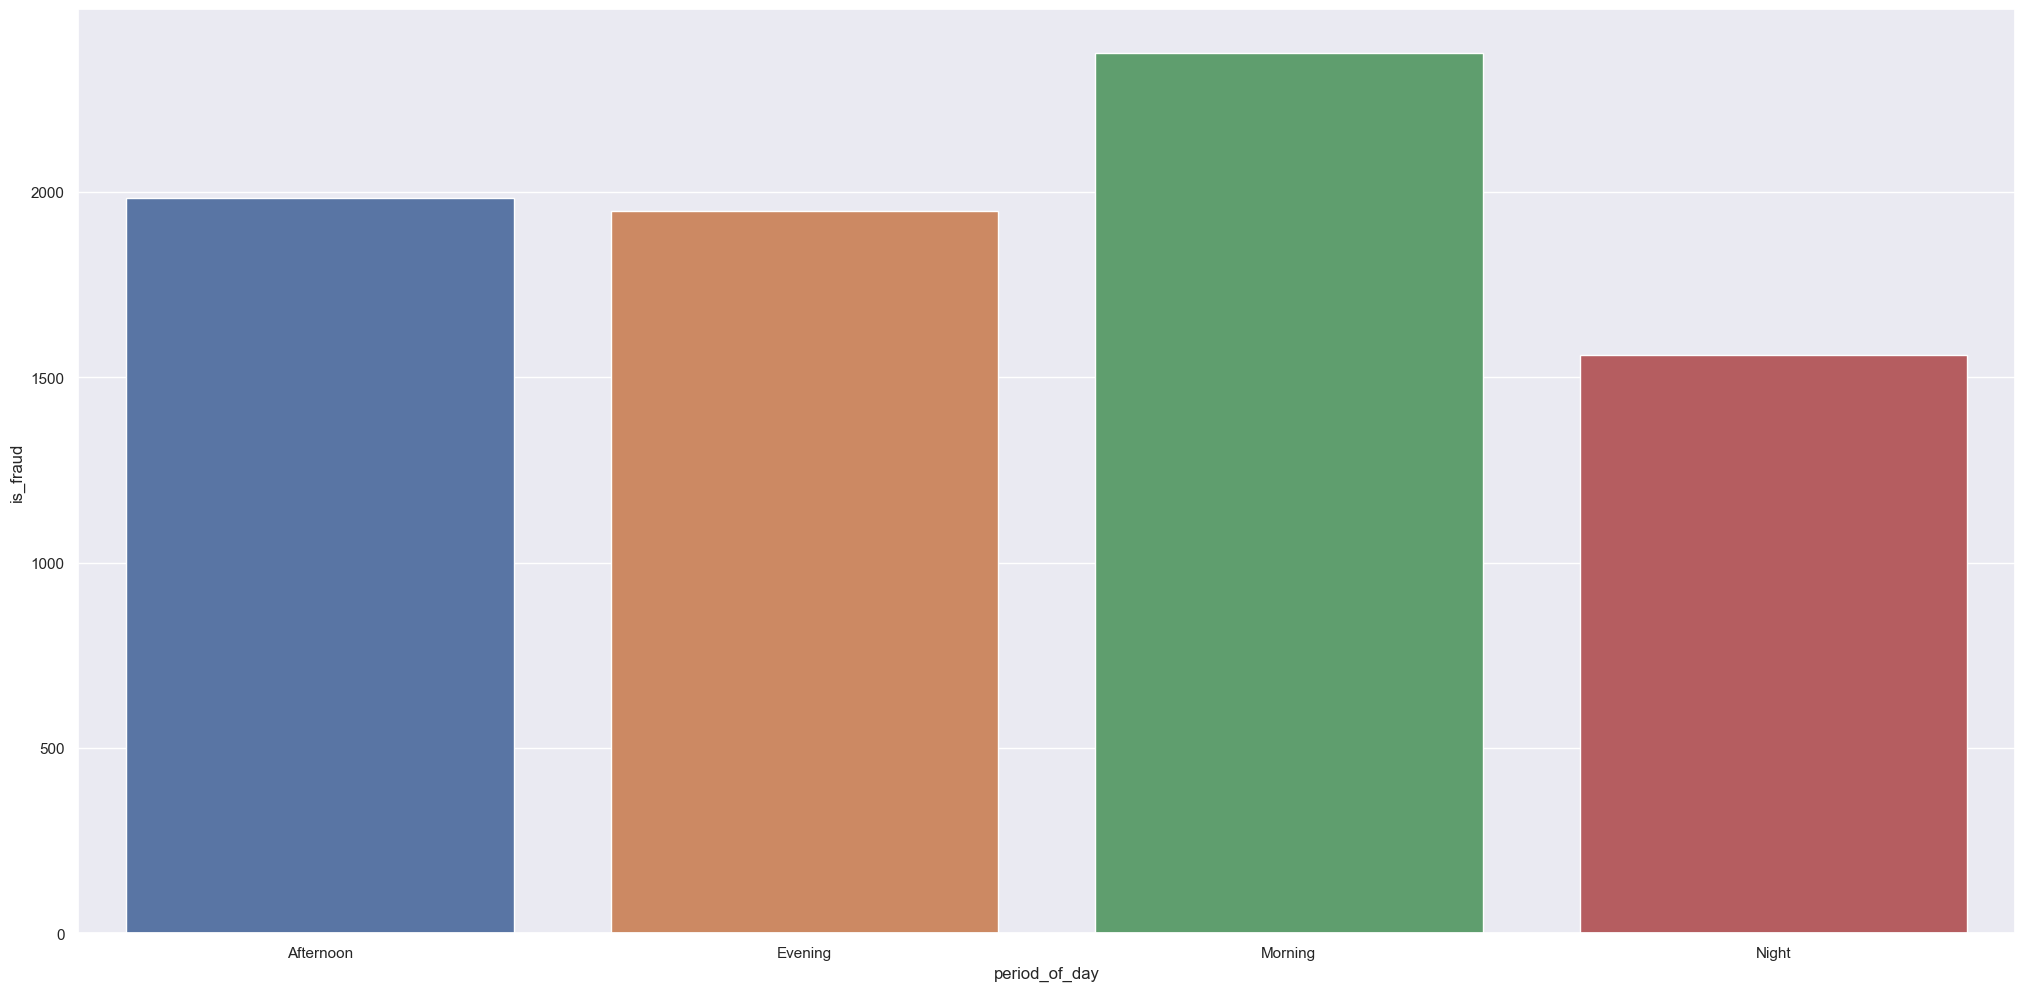

In [41]:
# Periodo do dia que mais ocorrem fraudes

aux1 = df4[['period_of_day', 'is_fraud']].groupby('period_of_day').sum().reset_index()

sns.barplot( x='period_of_day', y='is_fraud', data=aux1, hue='period_of_day')

In [42]:
df4.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night
9,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night
10,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night


In [43]:
# Quantidade de transações fraudulentas no qual o total enviado é igual ao valor total da conta
aux2 = df4[df4['amount'] == df4['oldbalance_org']]

aux2.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,1,1,Night
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,1,1,Night
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,1,1,Night
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,1,1,Night
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,1,1,Night


In [44]:
# Quantidade de transações válidas: 4196921
# Quantidade de transações fraudulentas: 7869
# Quantidade de transações com flag de fraudulentas: 12

In [45]:
aux2.shape

(7836, 14)

In [46]:
# As transações que são fraudes, geralmente são aquelas transações que "limpam" o valor da conta do cliente.

In [47]:
# Não existe clientes que fizeram mais de uma transação fraudulenta
fraude_por_cliente = df4[df4['is_fraud'] == 1].groupby('name_orig').size().reset_index(name='fraude_total')

In [48]:
df_fraud_aux = df4.merge(fraude_por_cliente, on='name_orig', how='left')

In [49]:
df_fraud_aux['fraude_total'] = df_fraud_aux['fraude_total'].fillna(0)
df_fraud_aux.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day,fraude_total
0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night,1.0
1,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night,1.0
2,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night,0.0
3,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night,0.0
4,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night,0.0


<Axes: xlabel='fraude_total', ylabel='count'>

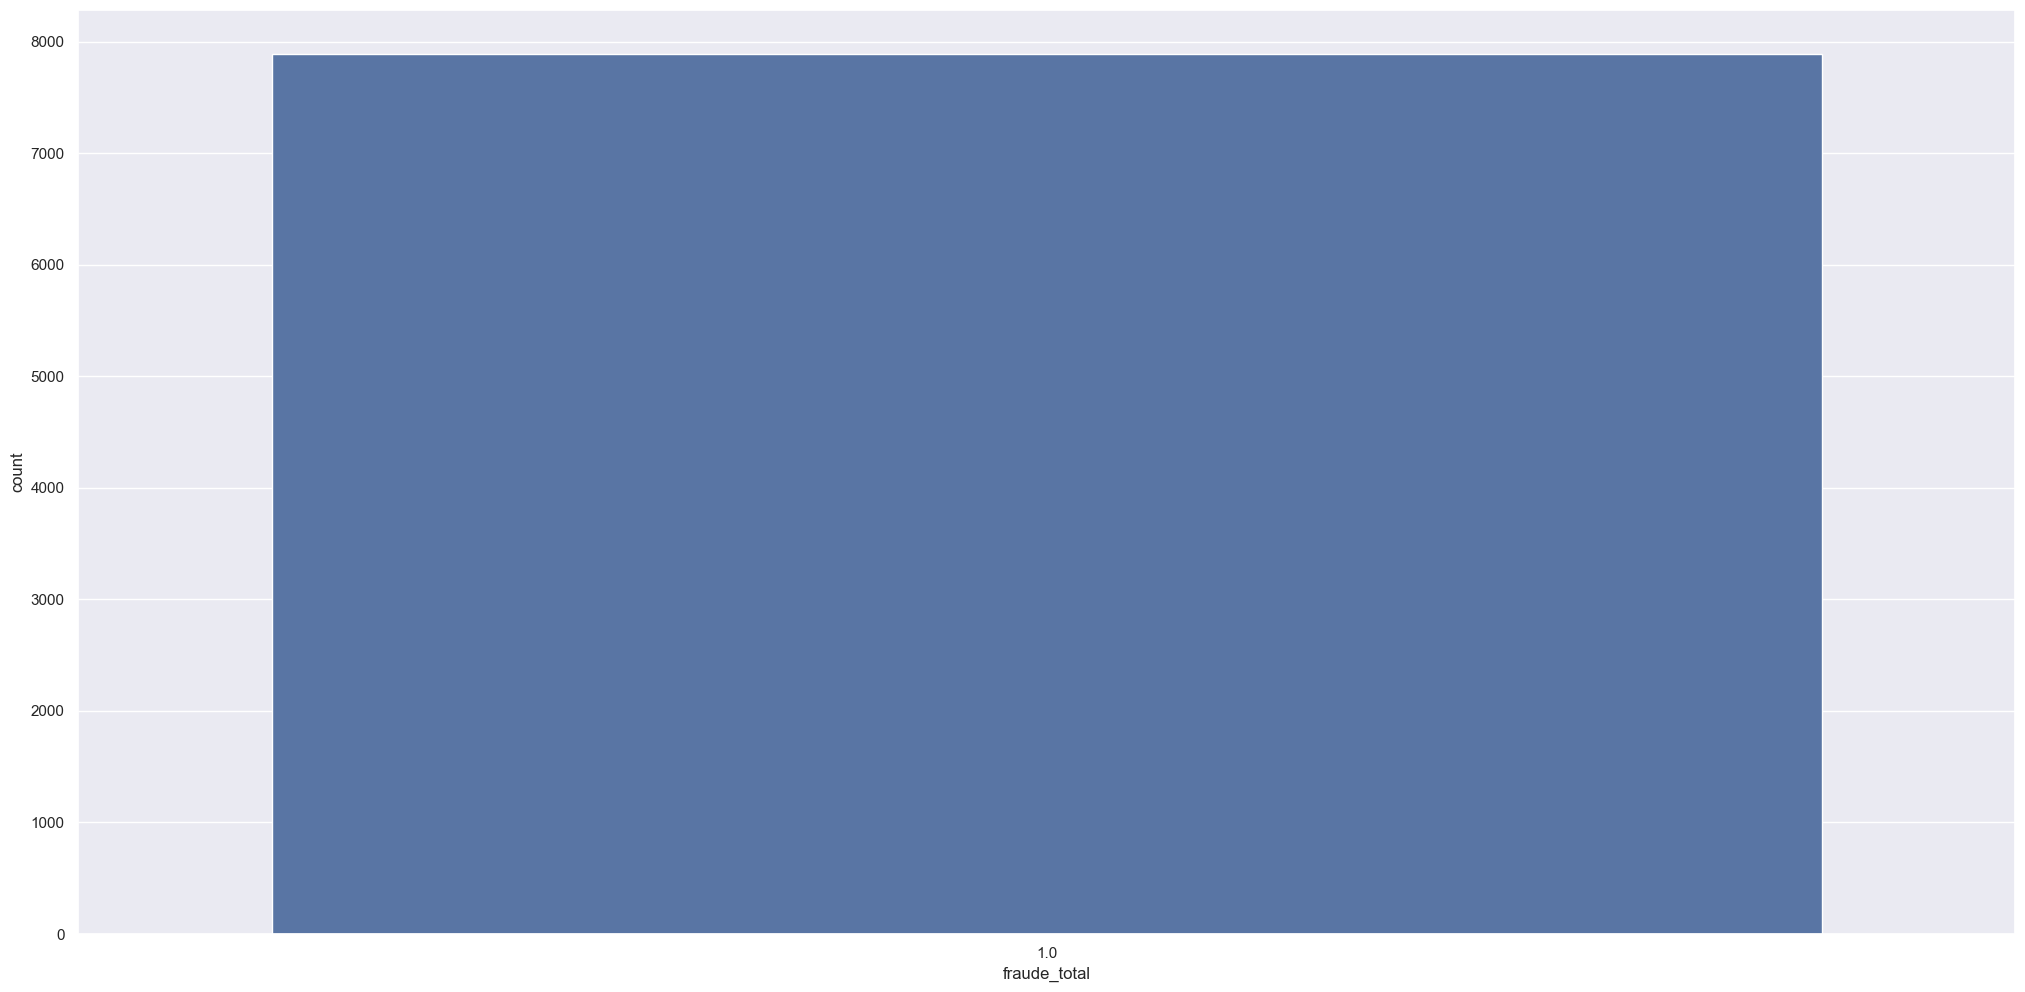

In [50]:

sns.countplot(data=df_fraud_aux[df_fraud_aux['fraude_total'] > 0], x='fraude_total')

## 4.3 Análise Multivariada

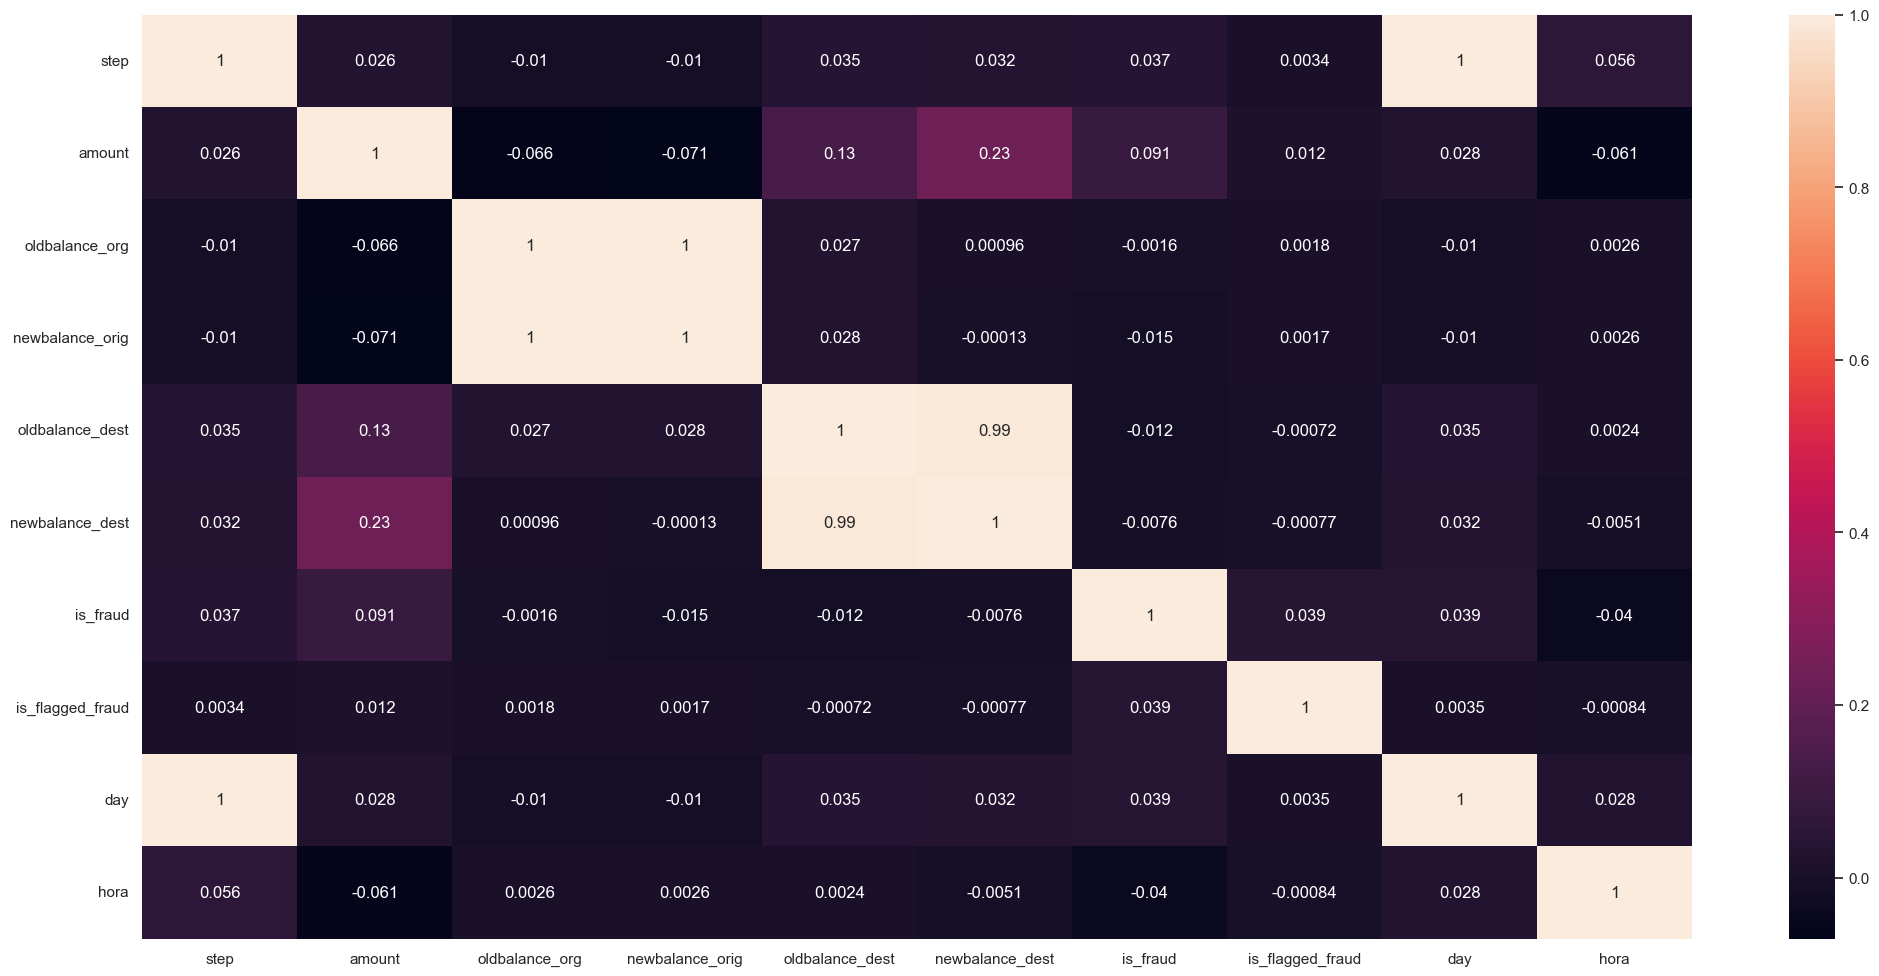

In [51]:
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True);

# 5.0 Data Preparation

In [52]:
df5 = df4.copy()

In [54]:
X = df5.copy()
y = df5['is_fraud']
X = X.drop('is_fraud', axis=1)

## 5.2 Train Test Validation Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42, stratify=y)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.2, random_state=42, stratify=y_test)

## 5.3 Pipeline Build

In [79]:
log_cols = ['amount', 'oldbalance_org', 'newbalance_orig', 'oldbalance_dest', 'newbalance_dest']
cat_cols = ['type']
cols_drop = ['name_orig', 'name_dest', 'period_of_day', 'hora', 'day']

dropper = FunctionTransformer(
                            drop_columns,
                            kw_args={'cols': cols_drop})

In [80]:
# Log Pipeline
log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p))
])

# Cat Pipeline
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder())
])

# Preprocessing Pipeline
preprocessing = ColumnTransformer([
    ('log', log_pipeline, log_cols),
    ('cat', cat_pipeline, cat_cols)
])



# 7.0 Machine Learning Modeling

In [131]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 7.1 Random Forest Classifier

In [83]:
#define

rfc = en.RandomForestClassifier(max_depth=15, n_estimators=50)

# train
model_pipeline = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', rfc)
])

model_pipeline.fit(X_train, y_train)

# performace 

y_hat_test = model_pipeline.predict(X_test)




In [85]:
acc = mt.accuracy_score(y_test, y_hat_test)

precision = mt.precision_score(y_test, y_hat_test)

recall = mt.recall_score(y_test, y_hat_test)

f1_score = mt.f1_score(y_test, y_hat_test)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9994634092686016
Precision: 0.9848812095032398
Recall: 0.7243844320889595
F1-Score: 0.8347826086956521


In [86]:
mt.balanced_accuracy_score(y_test,y_hat_test)

np.float64(0.8621817917302135)

In [ ]:
scores_rfc = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    scoring='balanced_accuracy',
    cv=cv)

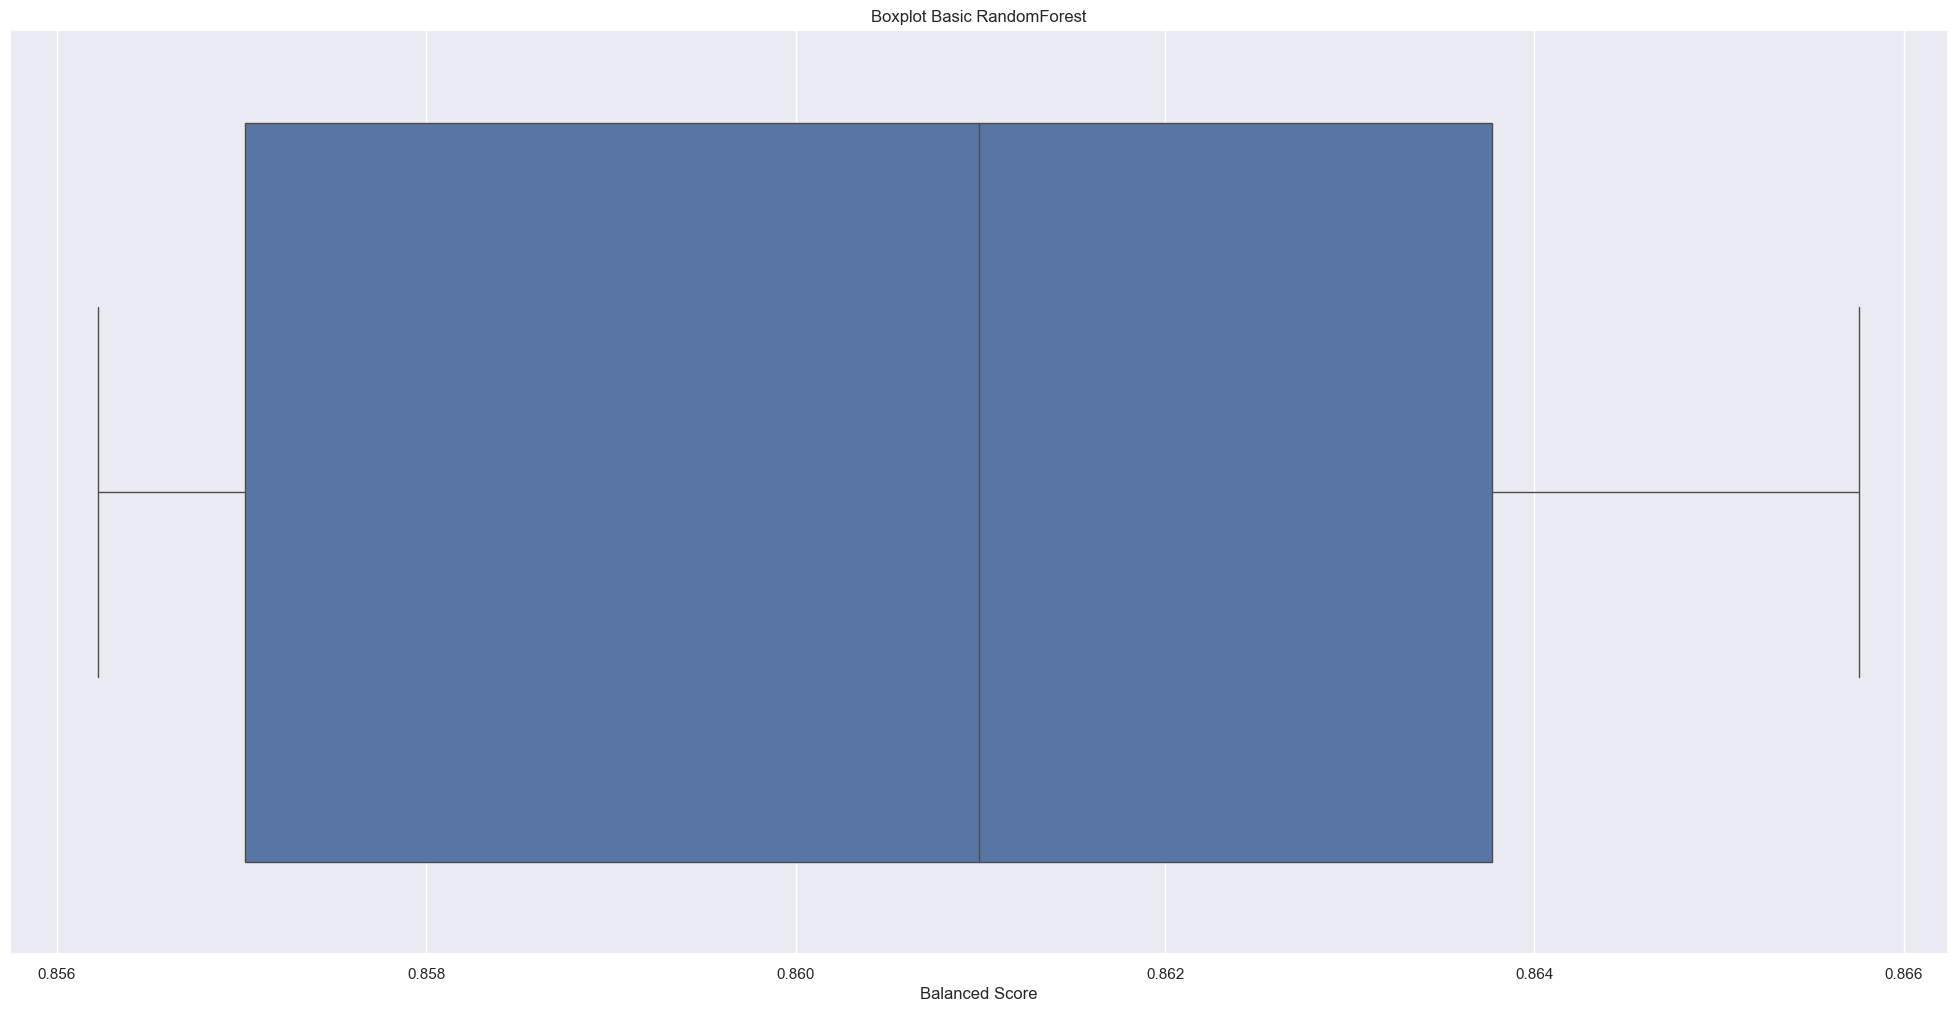

In [88]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_rfc['test_score'])
plt.title('Boxplot Basic RandomForest')
plt.xlabel('Balanced Score')
plt.show()

### Random Forest Tunned

In [69]:
rf_tunned = TunedThresholdClassifierCV(rfc, scoring="balanced_accuracy").fit(X_train, y_train)

In [70]:
print(f"Cut-off point found at {rf_tunned.best_threshold_:.3f}")

Cut-off point found at 0.010


In [91]:
y_test_tunned = model_pipeline.predict_proba(X_test)

In [92]:
yhat_tunned = y_test_tunned[:,1]
th = 0.010
yhat_tunned_a = [1 if i > th else 0 for i in yhat_tunned]

In [93]:
acc = mt.accuracy_score(y_test, yhat_tunned_a)

precision = mt.precision_score(y_test, yhat_tunned_a)

recall = mt.recall_score(y_test, yhat_tunned_a)

f1_score = mt.f1_score(y_test, yhat_tunned_a)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9932636310396186
Precision: 0.2140485759217194
Recall: 0.9729944400317713
F1-Score: 0.3509023202520768


In [94]:
mt.balanced_accuracy_score(y_test,yhat_tunned_a)

np.float64(0.9831480367609085)

In [95]:
mt.confusion_matrix(y_test,y_hat_test)

array([[671493,     14],
       [   347,    912]])

In [ ]:
# scores_rfc_tunned = cross_validate(rfc, X_train_val, y_train_val, scoring='balanced_accuracy')

In [78]:
# acc = mt.accuracy_score(y_train_val, yhat_test)

# precision = mt.precision_score(y_train_val, yhat_test)

# recall = mt.recall_score(y_train_val, yhat_test)

# f1_score = mt.f1_score(y_train_val, yhat_test)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')

In [79]:
# fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

In [80]:
# plt.plot (fpr, tpr, marker='.')
# plt.xlabel ('False Positive Rate')
# plt.ylabel ('True Positive Rate')

In [81]:
# plt.plot (threshold, tpr, 'b--', label='TPR')
# plt.plot (threshold, 1-fpr, 'g--', label='FPR')
# plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
# plt.legend()

## 7.2 Logistic Regression

In [99]:
# definition

lr = lm.LogisticRegression(max_iter=1000)

# training (fit)

model_pipeline_lr = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', lr)
])

model_pipeline_lr.fit(X_train, y_train)
# performace

y_hat_test_logistic = model_pipeline_lr.predict(X_test)

acc_lr = mt.accuracy_score(y_test, y_hat_test)

precision_lr = mt.precision_score(y_test, y_hat_test)

recall_lr = mt.recall_score(y_test, y_hat_test)

f1_score_lr = mt.f1_score(y_test, y_hat_test)

print(f'Acurácia: {acc_lr}')
print(f'Precision: {precision_lr}')
print(f'Recall: {recall_lr}')
print(f'F1-Score: {f1_score_lr}')

Acurácia: 0.9994634092686016
Precision: 0.9848812095032398
Recall: 0.7243844320889595
F1-Score: 0.8347826086956521


In [101]:
scores_logistic = cross_validate(model_pipeline_lr, X_train, y_train, scoring='balanced_accuracy')

In [102]:
scores_logistic

{'fit_time': array([7.36607766, 7.6705873 , 7.00720263, 7.37079406, 9.71522689]),
 'score_time': array([0.3169806 , 0.30488706, 0.30832791, 0.35491586, 0.36578226]),
 'test_score': array([0.74817489, 0.73903917, 0.74460286, 0.75652825, 0.73903991])}

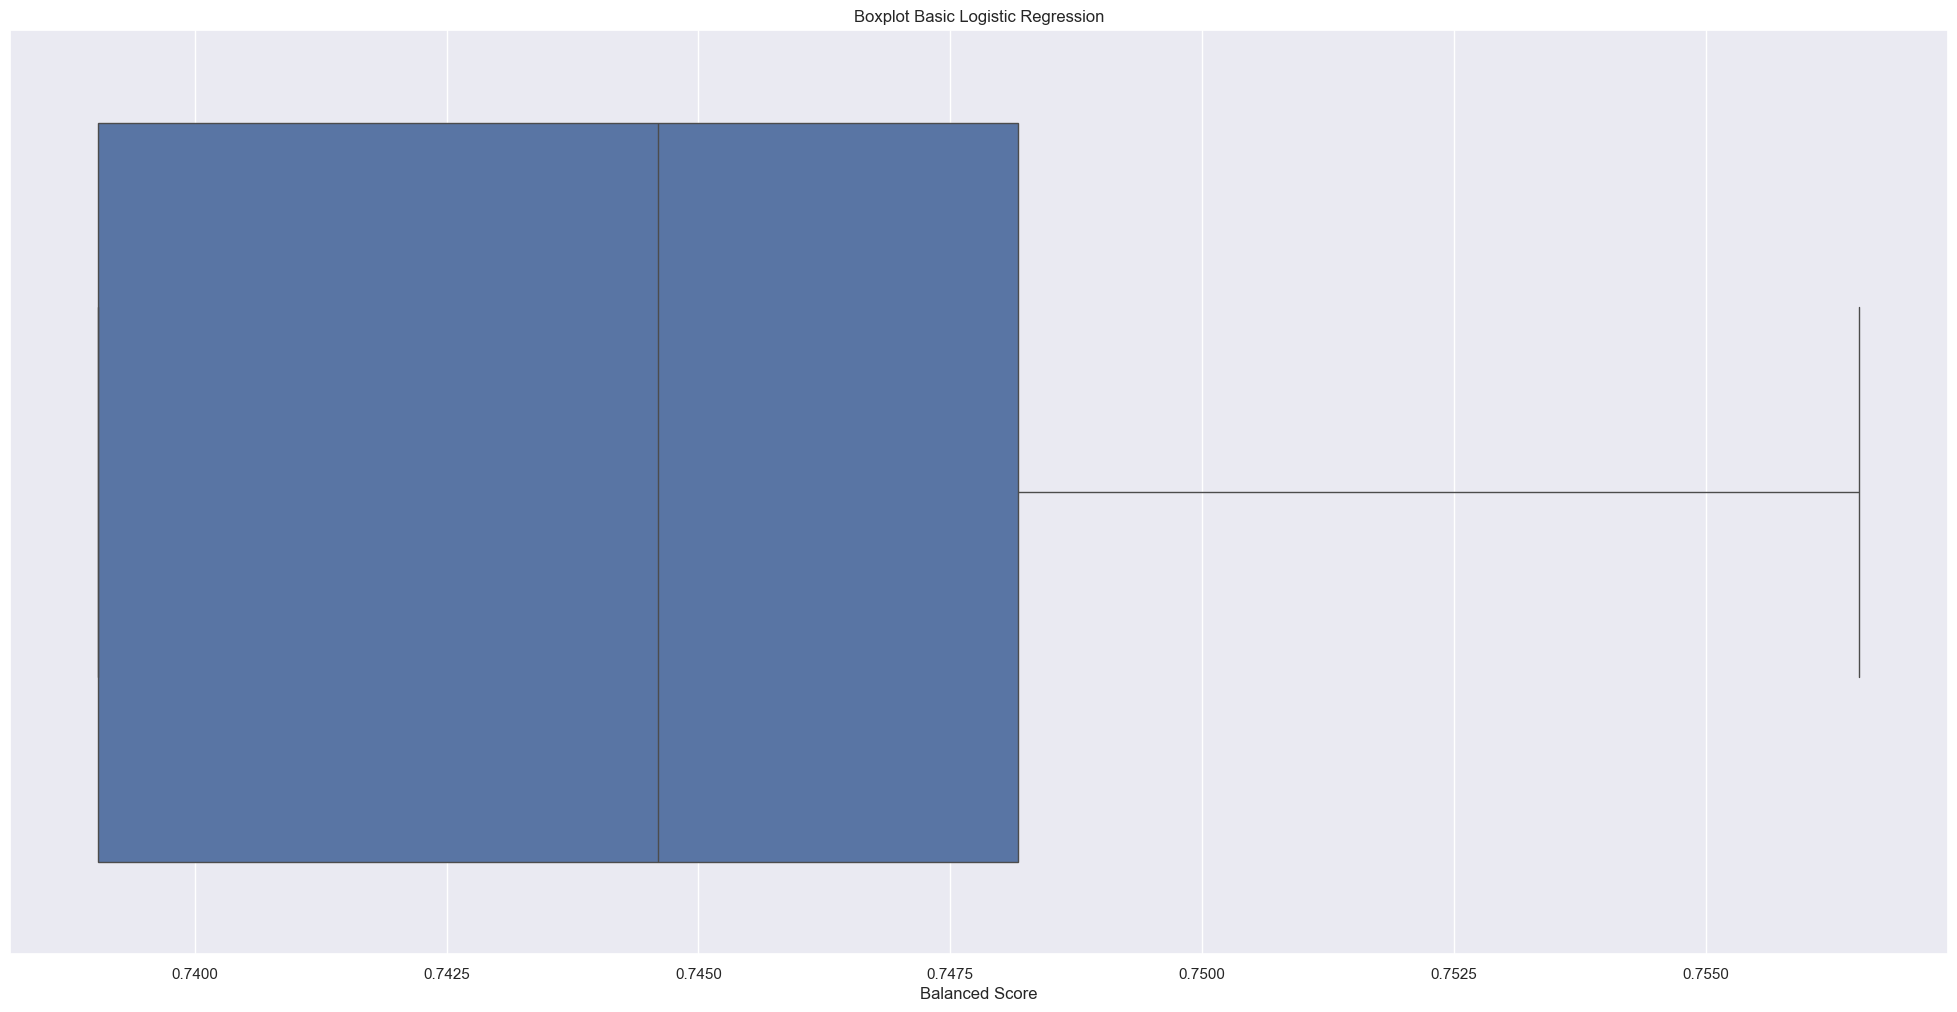

In [103]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_logistic['test_score'])
plt.title('Boxplot Basic Logistic Regression')
plt.xlabel('Balanced Score')
plt.show()

In [107]:
mt.confusion_matrix(y_test, y_hat_test_logistic)

array([[671451,     56],
       [   630,    629]])

In [109]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test_logistic)

Text(0, 0.5, 'True Positive Rate')

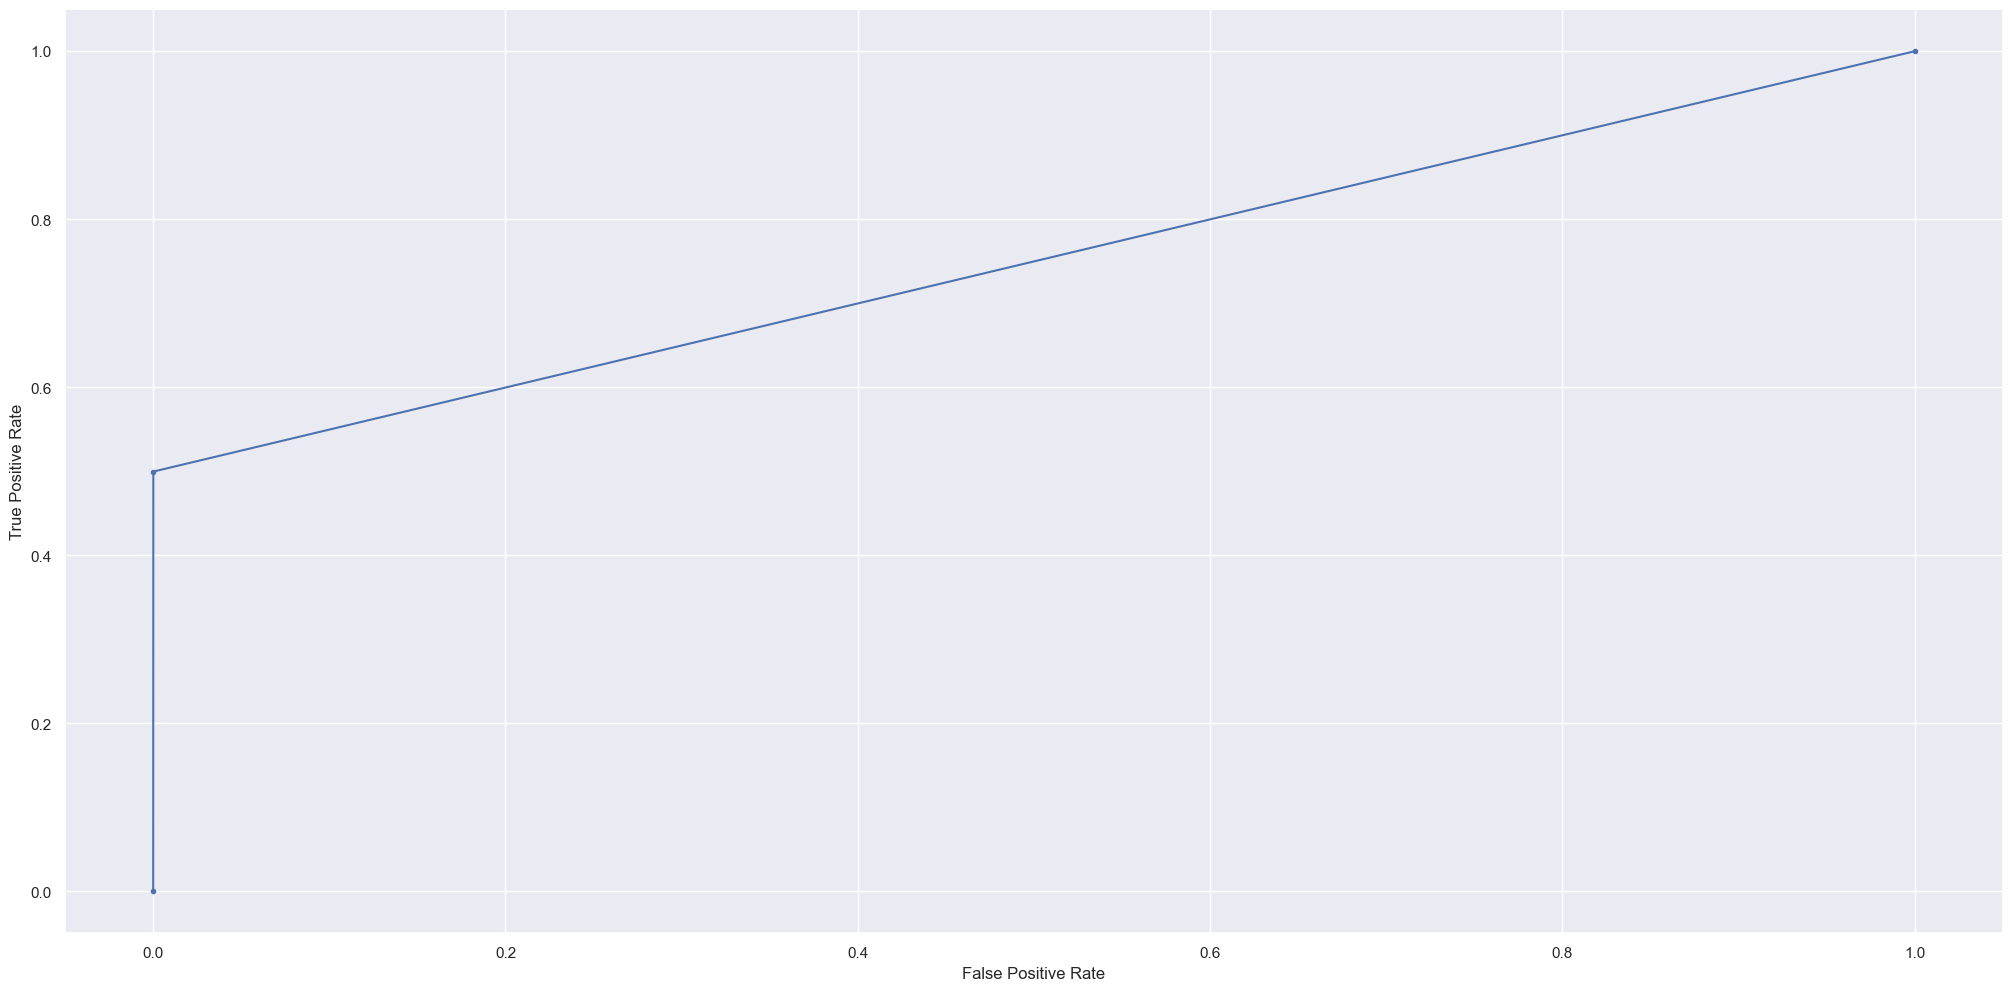

In [110]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

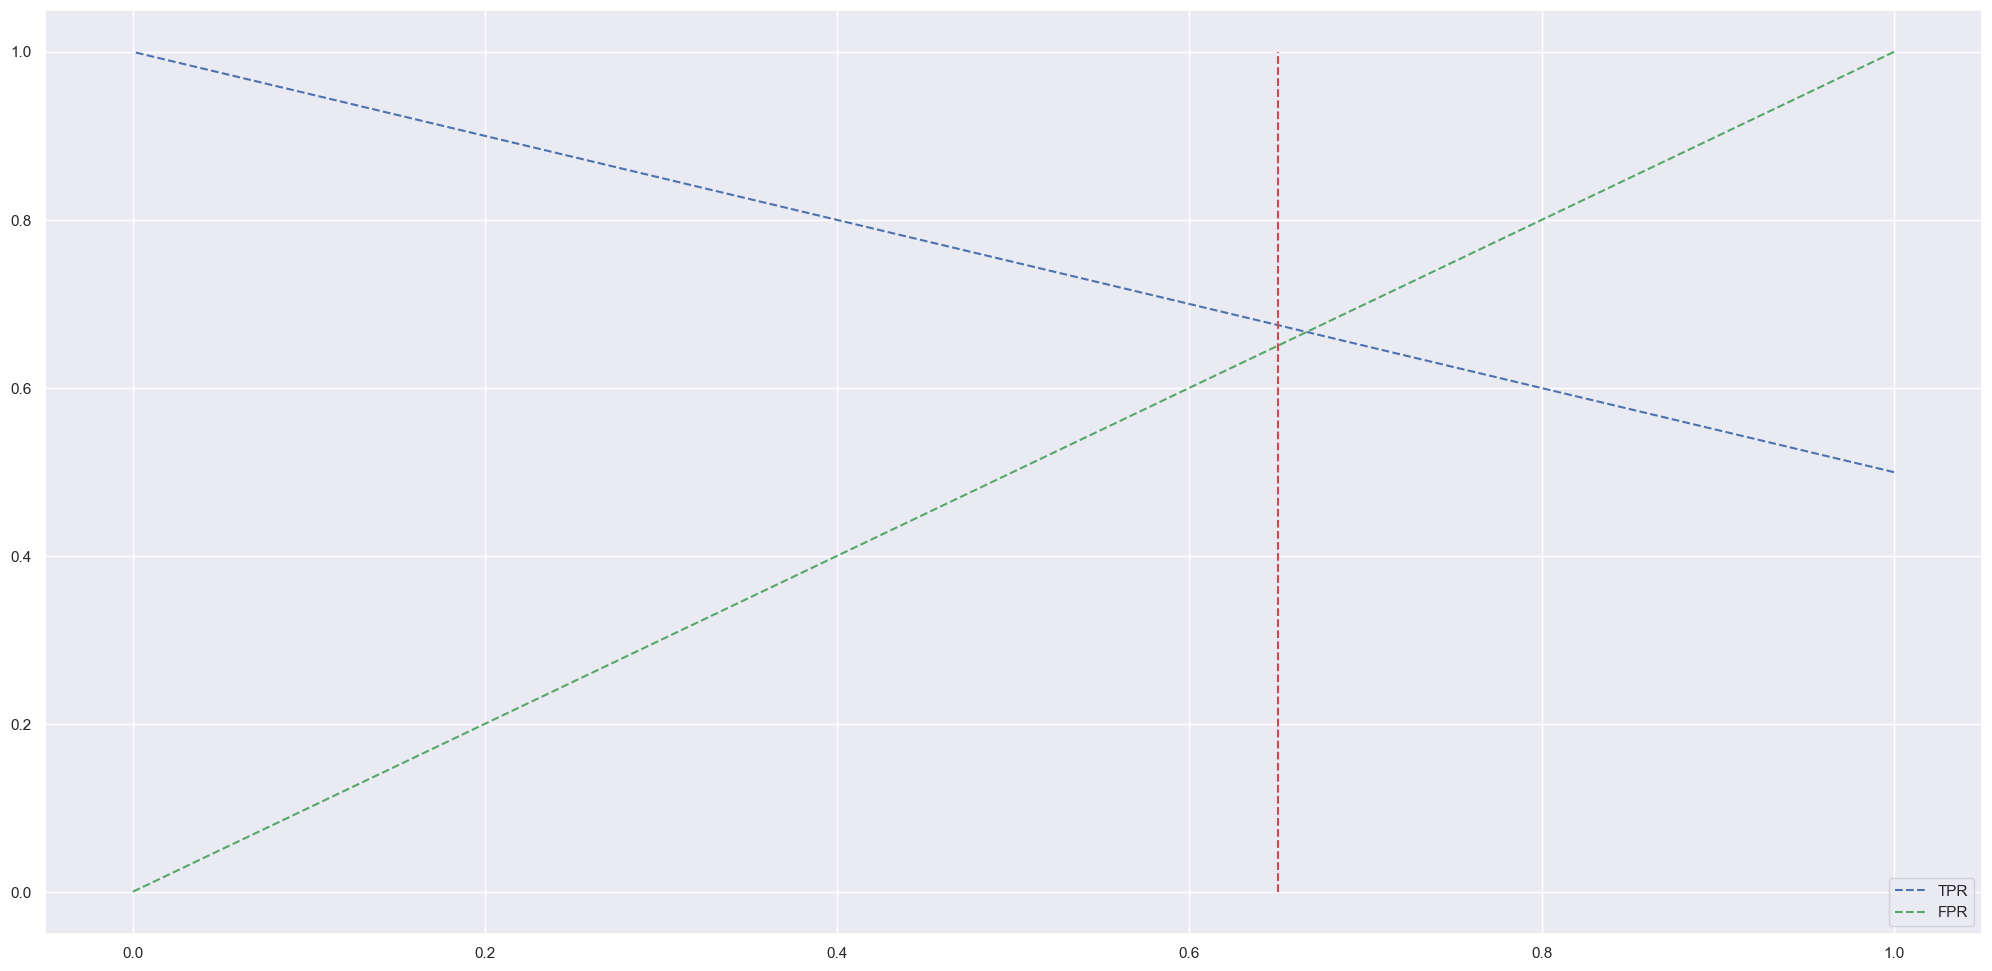

In [111]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
plt.legend()

In [ ]:
# df_resultados = pd.DataFrame({
#     'Modelo': ['RandomForest'] * len(scores['test_score']) + ['LogisticRegression'] * len(scores_logistic['test_score']),
#     'Test Score': list(scores['test_score']) + list(scores_logistic['test_score'])
# })

In [112]:
# sns.boxplot(x='Test Score', y='Modelo', data=df_resultados)
# plt.title('Comparação de Balanced Accuracy entre Modelos')
# plt.xlabel('Balanced Accuracy')
# plt.grid(True)
# plt.show()

## 7.3 XGBoost

In [139]:
# definition

xgb_model = xgb.XGBClassifier(n_estimators=50, max_depth=15, learning_rate=1, objective='binary:logistic')

# fit
model_pipeline_xgb = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', xgb_model)
])
model_pipeline_xgb.fit(X_train, y_train)

# performace

y_hat_test_xgb= model_pipeline_xgb.predict(X_test)



In [ ]:
# y_hat_test_xgb = y_hat_test_xgb[:,1]
# th = 0.010
# yhat_tunned_xgb = [1 if i > th else 0 for i in y_hat_test_xgb]

In [140]:
acc = mt.accuracy_score(y_test, y_hat_test_xgb)
precision = mt.precision_score(y_test, y_hat_test_xgb)
recall = mt.recall_score(y_test, y_hat_test_xgb)
f1_score = mt.f1_score(y_test, y_hat_test_xgb)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9971148958181597
Precision: 0.23969465648854962
Recall: 0.2494042891183479
F1-Score: 0.24445309458933437


In [132]:
scores_xgb = cross_validate(model_pipeline_xgb,
                             X_train,
                             y_train,
                             scoring='balanced_accuracy',
                             cv=cv)

In [135]:
scores_xgb

{'fit_time': array([16.23805642,  7.15352273,  7.49355316,  8.49956536,  7.60824609]),
 'score_time': array([0.51387191, 0.50363159, 0.50870395, 0.56355548, 0.55198598]),
 'test_score': array([0.69218356, 0.5237508 , 0.53430058, 0.58023262, 0.51556024])}

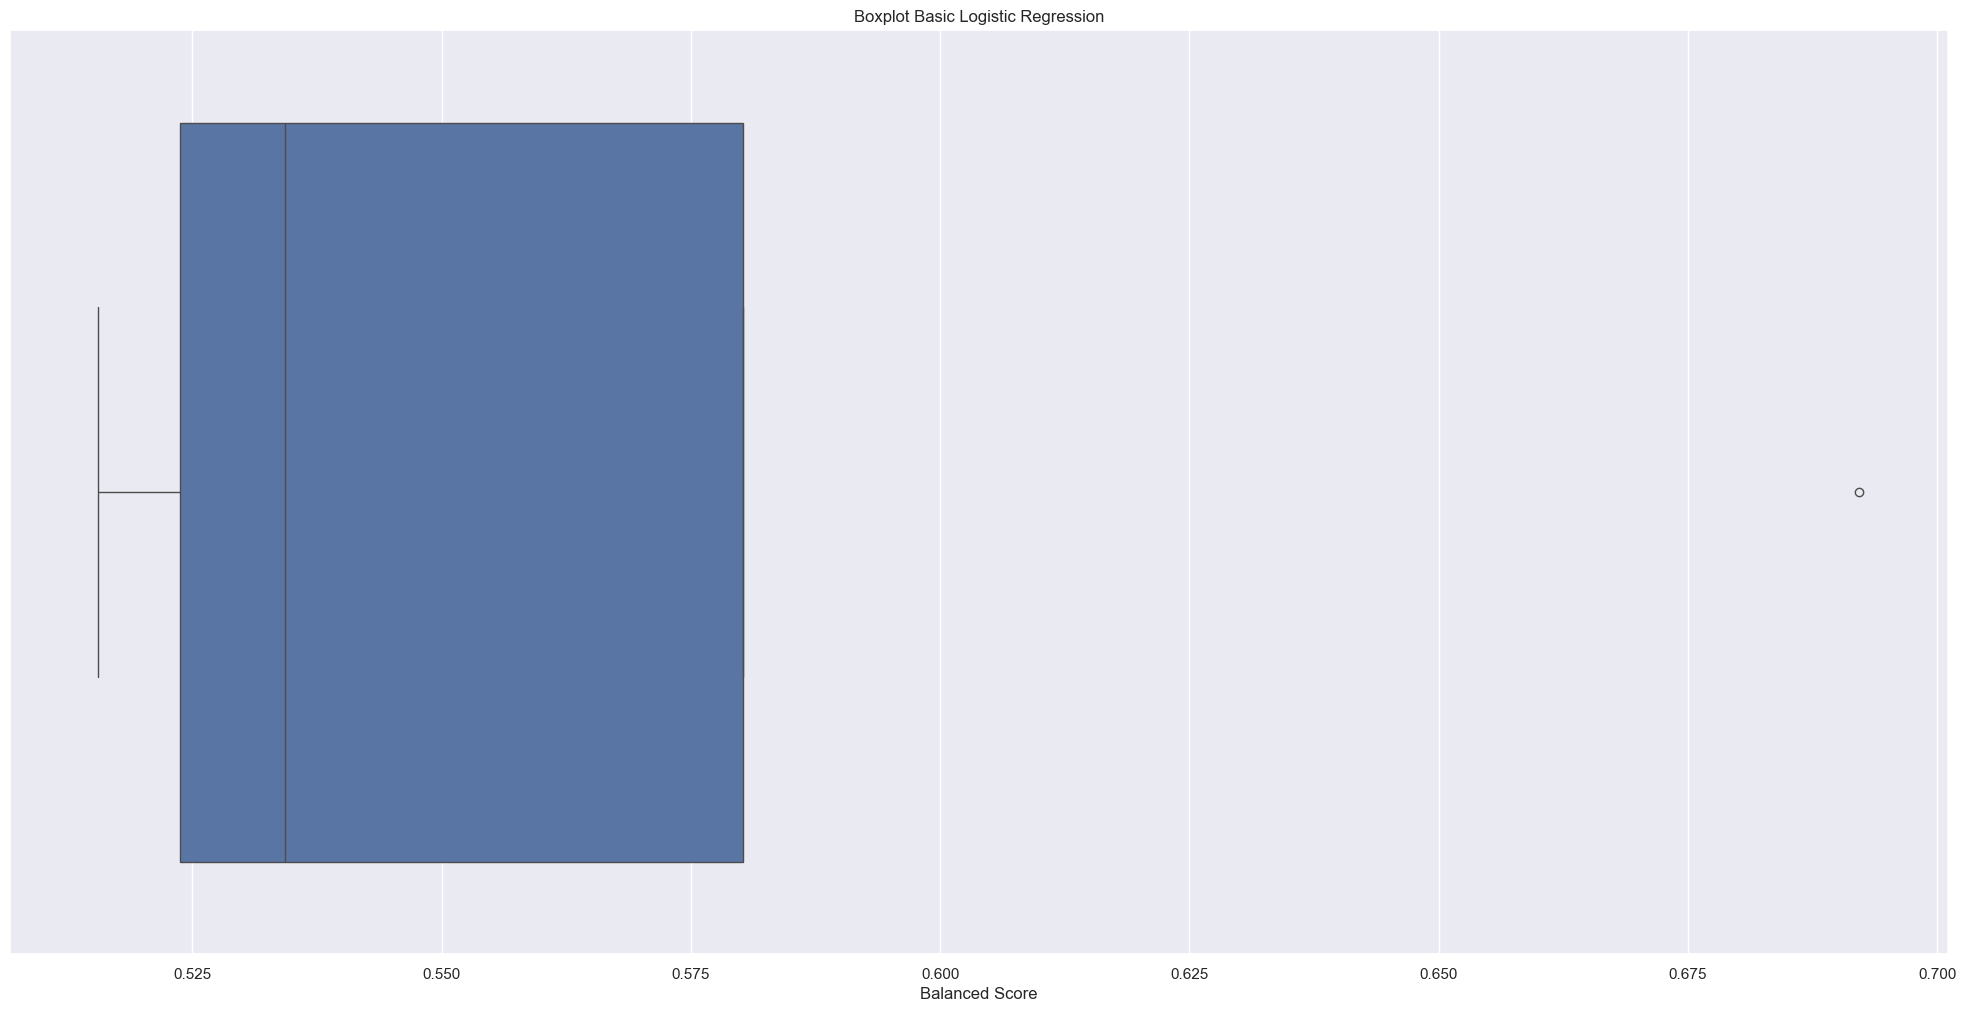

In [134]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_xgb['test_score'])
plt.title('Boxplot Basic Logistic Regression')
plt.xlabel('Balanced Score')
plt.show()

In [141]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test_xgb)

In [142]:
mt.balanced_accuracy_score(y_test,y_hat_test_xgb)

np.float64(0.6239605290585164)

Text(0, 0.5, 'True Positive Rate')

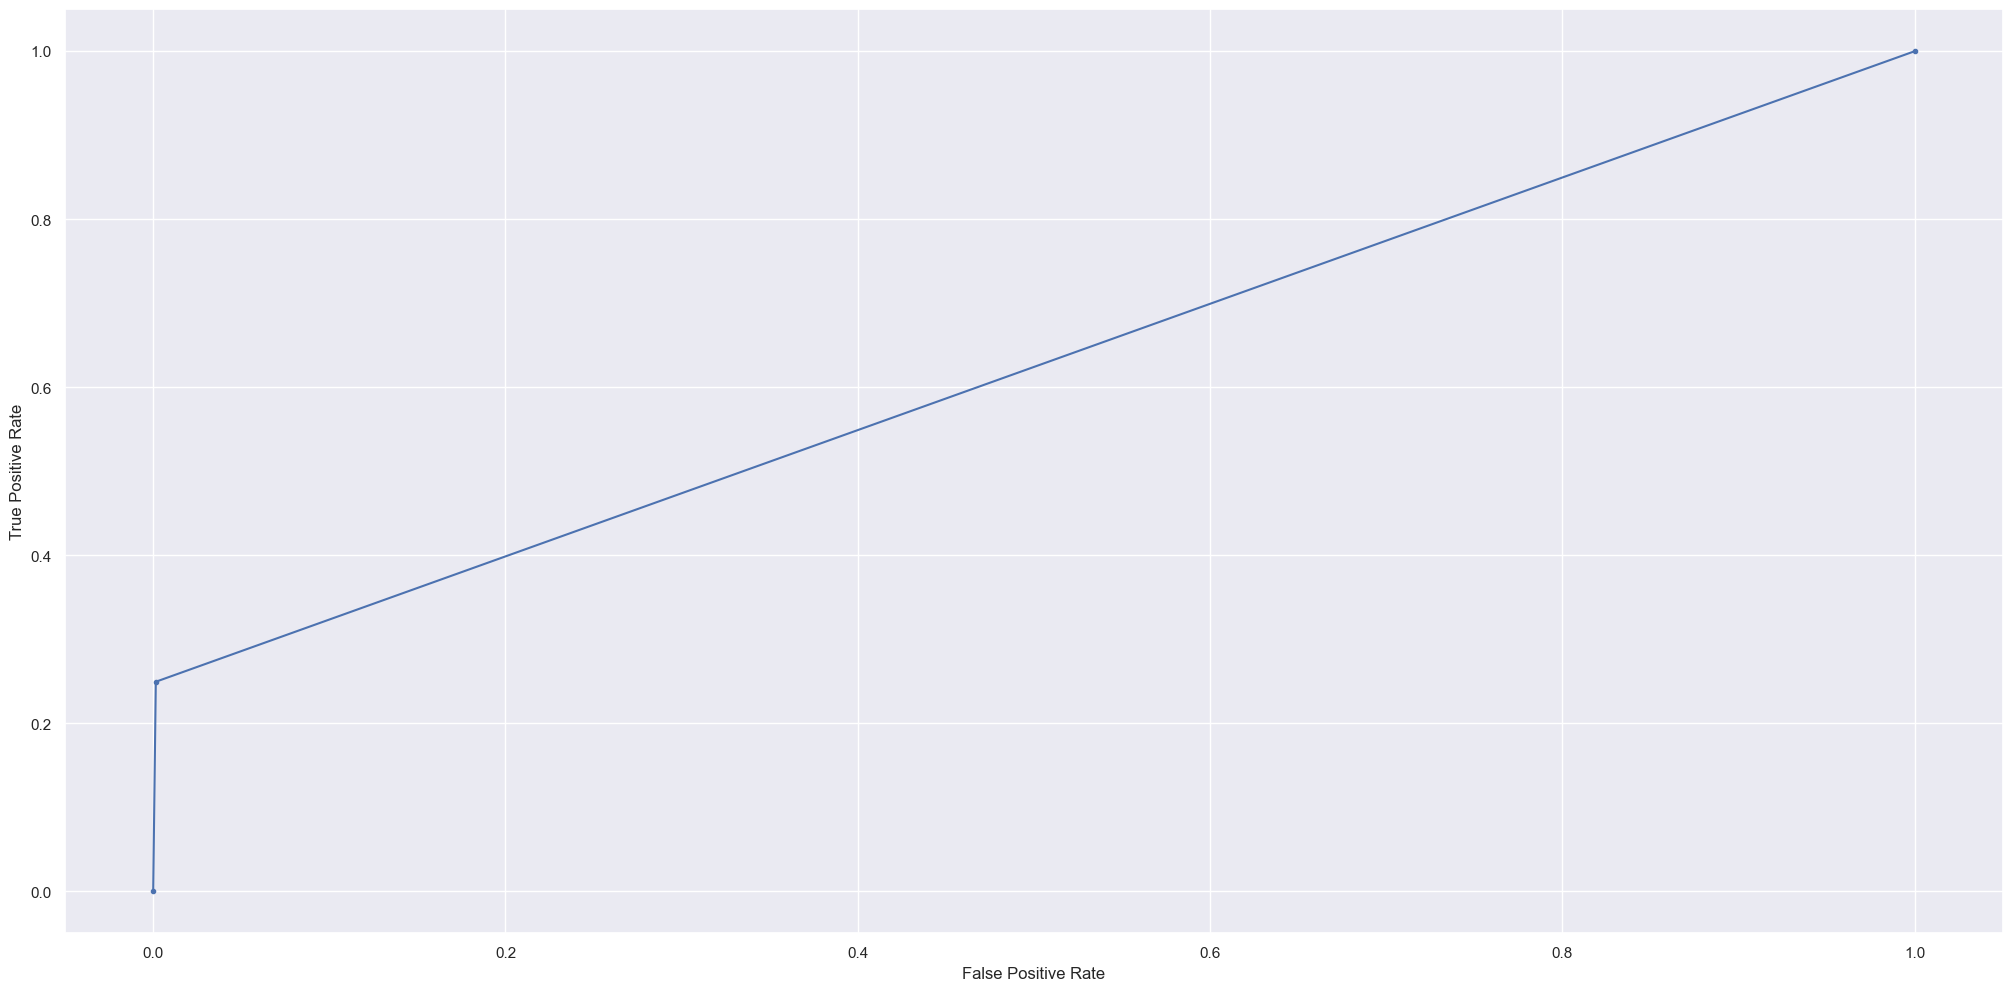

In [143]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

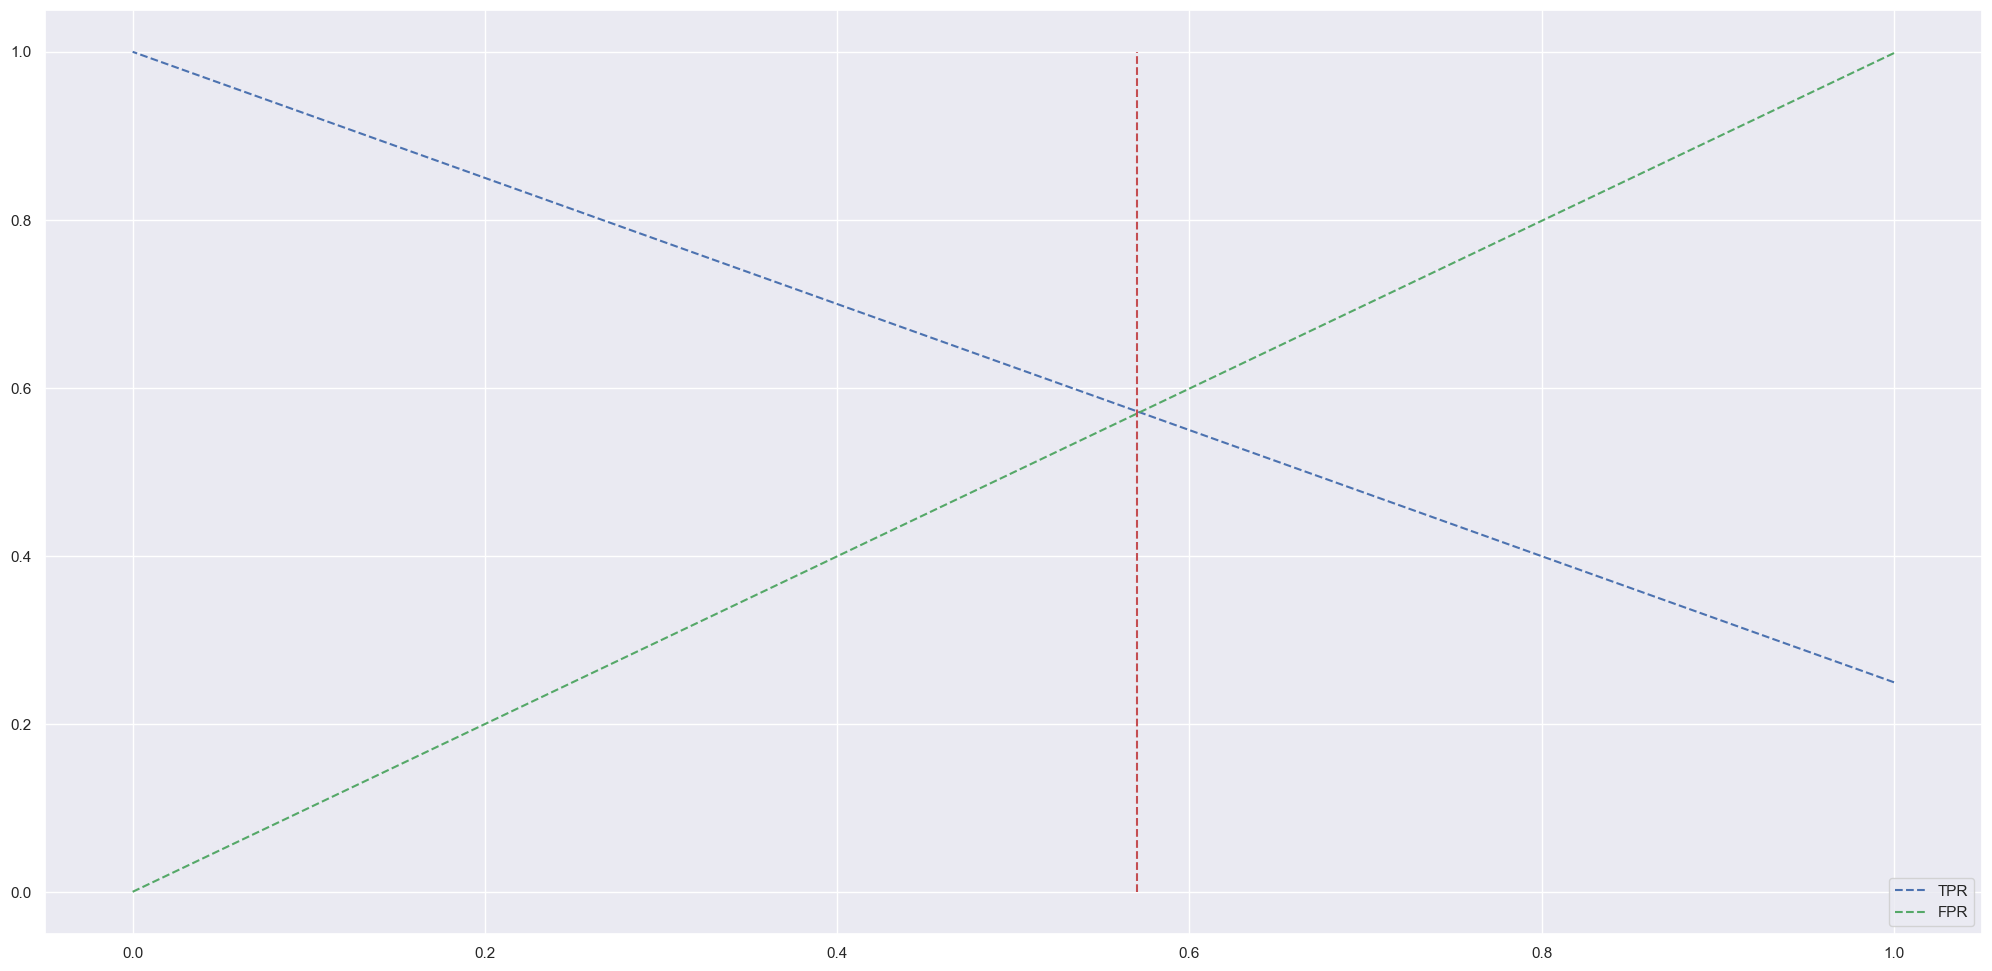

In [149]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.57, 0, 1, color='r', linestyles='--')
plt.legend()

In [118]:
mt.confusion_matrix(y_test, y_hat_test_xgb)

array([[670511,    996],
       [   945,    314]])

## 7.4 CATBoost

In [ ]:
# definition

cat_model = cat.CatBoostClassifier(max_depth=15, learning_rate=1)


model_pipeline_cat = Pipeline([
    ('drop', dropper),
    ('preprocessing', preprocessing),
    ('model', cat_model)
])
model_pipeline_cat.fit(X_train, y_train)
# performace

y_hat_test_cat= model_pipeline_cat.predict_proba(X_test)

0:	learn: 0.0056148	total: 864ms	remaining: 14m 22s
1:	learn: 0.0032586	total: 3.21s	remaining: 26m 42s
2:	learn: 0.0025686	total: 5.25s	remaining: 29m 3s
3:	learn: 0.0022995	total: 7.3s	remaining: 30m 17s
4:	learn: 0.0019910	total: 9.53s	remaining: 31m 36s
5:	learn: 0.0018957	total: 12.5s	remaining: 34m 25s
6:	learn: 0.0017892	total: 15.2s	remaining: 35m 55s
7:	learn: 0.0017580	total: 17.8s	remaining: 36m 48s
8:	learn: 0.0016122	total: 20.1s	remaining: 36m 53s
9:	learn: 0.0015604	total: 22.5s	remaining: 37m 10s
10:	learn: 0.0015109	total: 24.7s	remaining: 37m 4s
11:	learn: 0.0014785	total: 27.2s	remaining: 37m 18s
12:	learn: 0.0014544	total: 29.8s	remaining: 37m 38s
13:	learn: 0.0013738	total: 32s	remaining: 37m 34s
14:	learn: 0.0013368	total: 34.5s	remaining: 37m 44s
15:	learn: 0.0013026	total: 36.8s	remaining: 37m 42s
16:	learn: 0.0012854	total: 39.1s	remaining: 37m 42s
17:	learn: 0.0012630	total: 41.5s	remaining: 37m 44s
18:	learn: 0.0012432	total: 44.1s	remaining: 37m 57s
19:	lear

In [125]:
y_hat_test_cat= model_pipeline_cat.predict(X_test)

In [ ]:
# y_hat_test_cat = y_hat_test_cat[:,1]
# th = 0.010
# yhat_tunned_cat = [1 if i > th else 0 for i in y_hat_test_cat]

In [127]:
acc_cat = mt.accuracy_score(y_test, y_hat_test_cat)
precision_cat = mt.precision_score(y_test, y_hat_test_cat)
recall_cat = mt.recall_score(y_test, y_hat_test_cat)
f1_score_cat = mt.f1_score(y_test, y_hat_test_cat)

print(f'Acurácia: {acc_cat}')
print(f'Precision: {precision_cat}')
print(f'Recall: {recall_cat}')
print(f'F1-Score: {f1_score_cat}')

Acurácia: 0.9994425996557496
Precision: 0.8816925734024179
Recall: 0.8109610802223988
F1-Score: 0.8448489863467108


In [ ]:
scores_cat = cross_validate(cat_model,
                             X_train,
                             y_train,
                             scoring='balanced_accuracy',
                             cv=cv)

0:	learn: 0.0056563	total: 1.55s	remaining: 25m 52s
1:	learn: 0.0028564	total: 1.83s	remaining: 15m 15s
2:	learn: 0.0023724	total: 3.24s	remaining: 17m 56s
3:	learn: 0.0021256	total: 4.73s	remaining: 19m 37s
4:	learn: 0.0017552	total: 6.29s	remaining: 20m 51s
5:	learn: 0.0016651	total: 7.74s	remaining: 21m 22s
6:	learn: 0.0015316	total: 9.37s	remaining: 22m 9s
7:	learn: 0.0013964	total: 11s	remaining: 22m 47s
8:	learn: 0.0012442	total: 12.7s	remaining: 23m 16s
9:	learn: 0.0011315	total: 14.4s	remaining: 23m 42s
10:	learn: 0.0010531	total: 16.1s	remaining: 24m 11s
11:	learn: 0.0009939	total: 18s	remaining: 24m 41s
12:	learn: 0.0008818	total: 19.7s	remaining: 24m 58s
13:	learn: 0.0007937	total: 21.4s	remaining: 25m 4s
14:	learn: 0.0007071	total: 23s	remaining: 25m 8s
15:	learn: 0.0006844	total: 24.7s	remaining: 25m 16s
16:	learn: 0.0006626	total: 26.6s	remaining: 25m 38s
17:	learn: 0.0006502	total: 28.3s	remaining: 25m 42s
18:	learn: 0.0006396	total: 28.5s	remaining: 24m 30s
19:	learn: 0

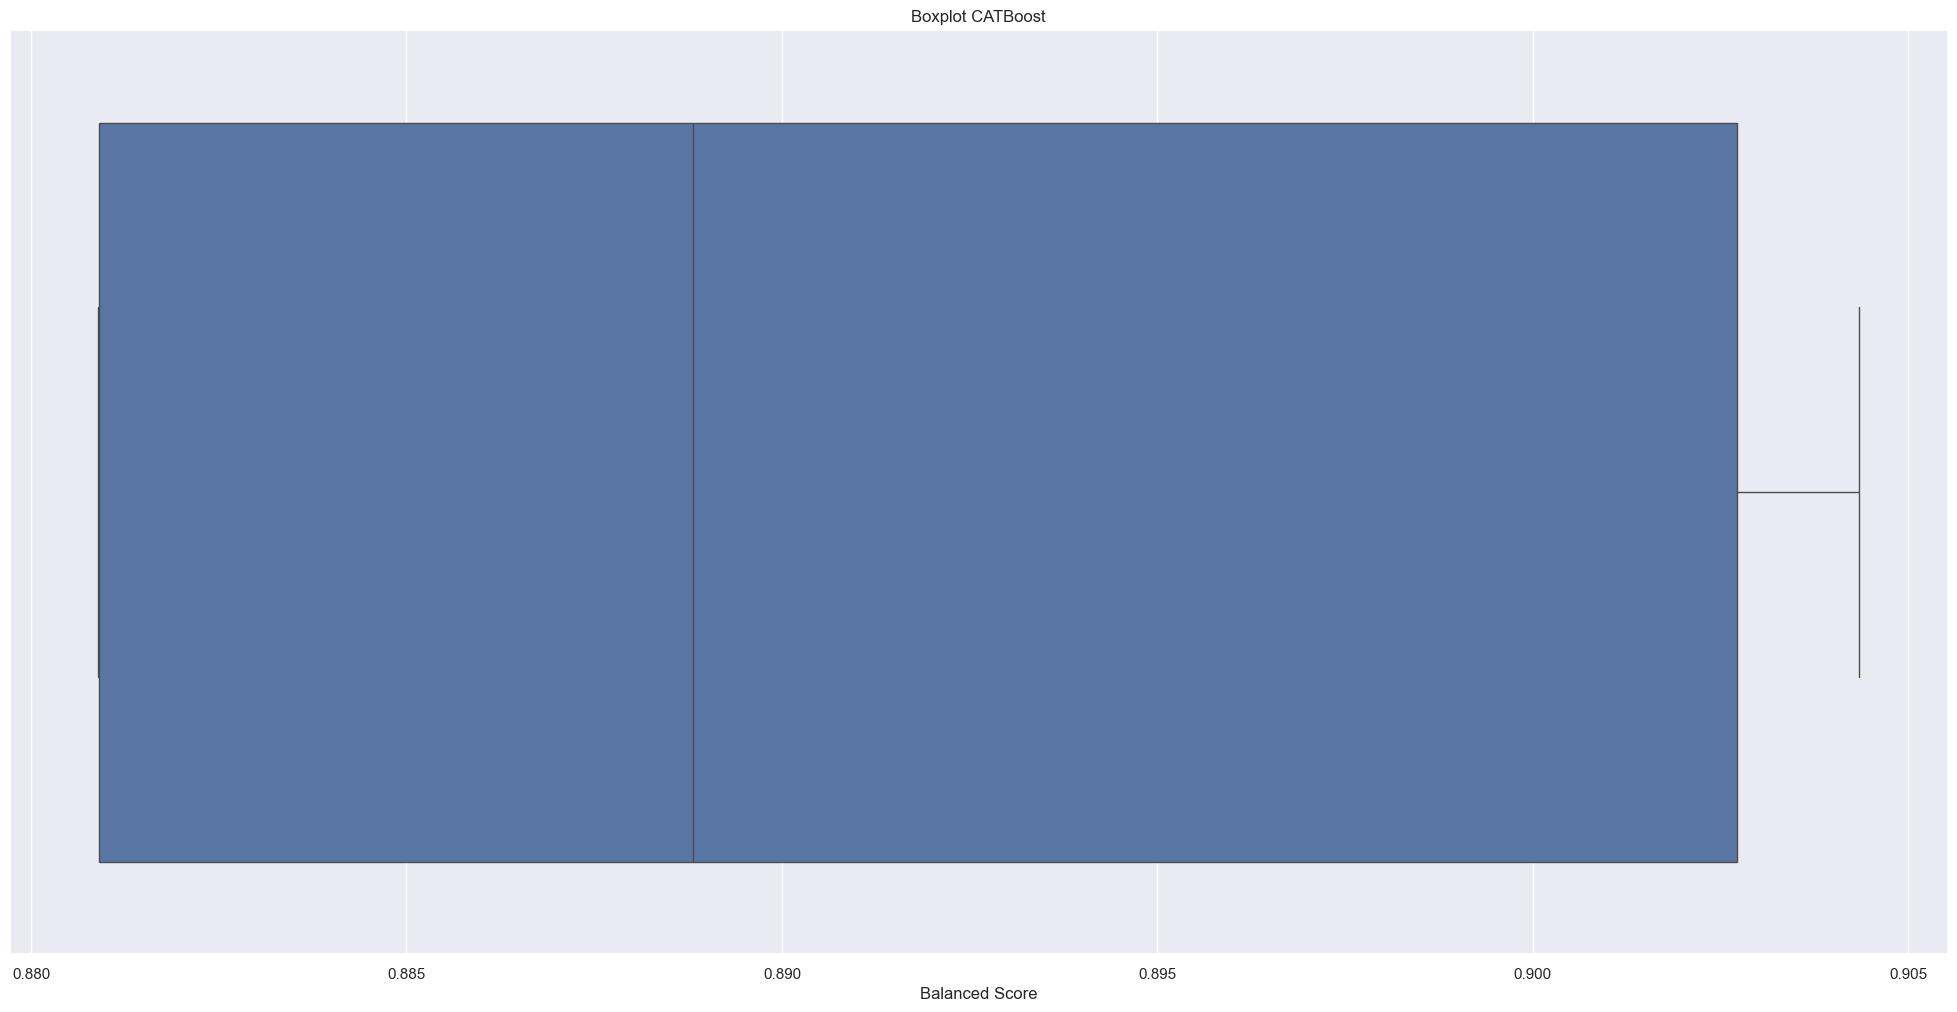

In [106]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_cat['test_score'])
plt.title('Boxplot CATBoost')
plt.xlabel('Balanced Score')
plt.show()

In [150]:
fpr, tpr, threshold = mt.roc_curve(y_test, y_hat_test_cat)

Text(0, 0.5, 'True Positive Rate')

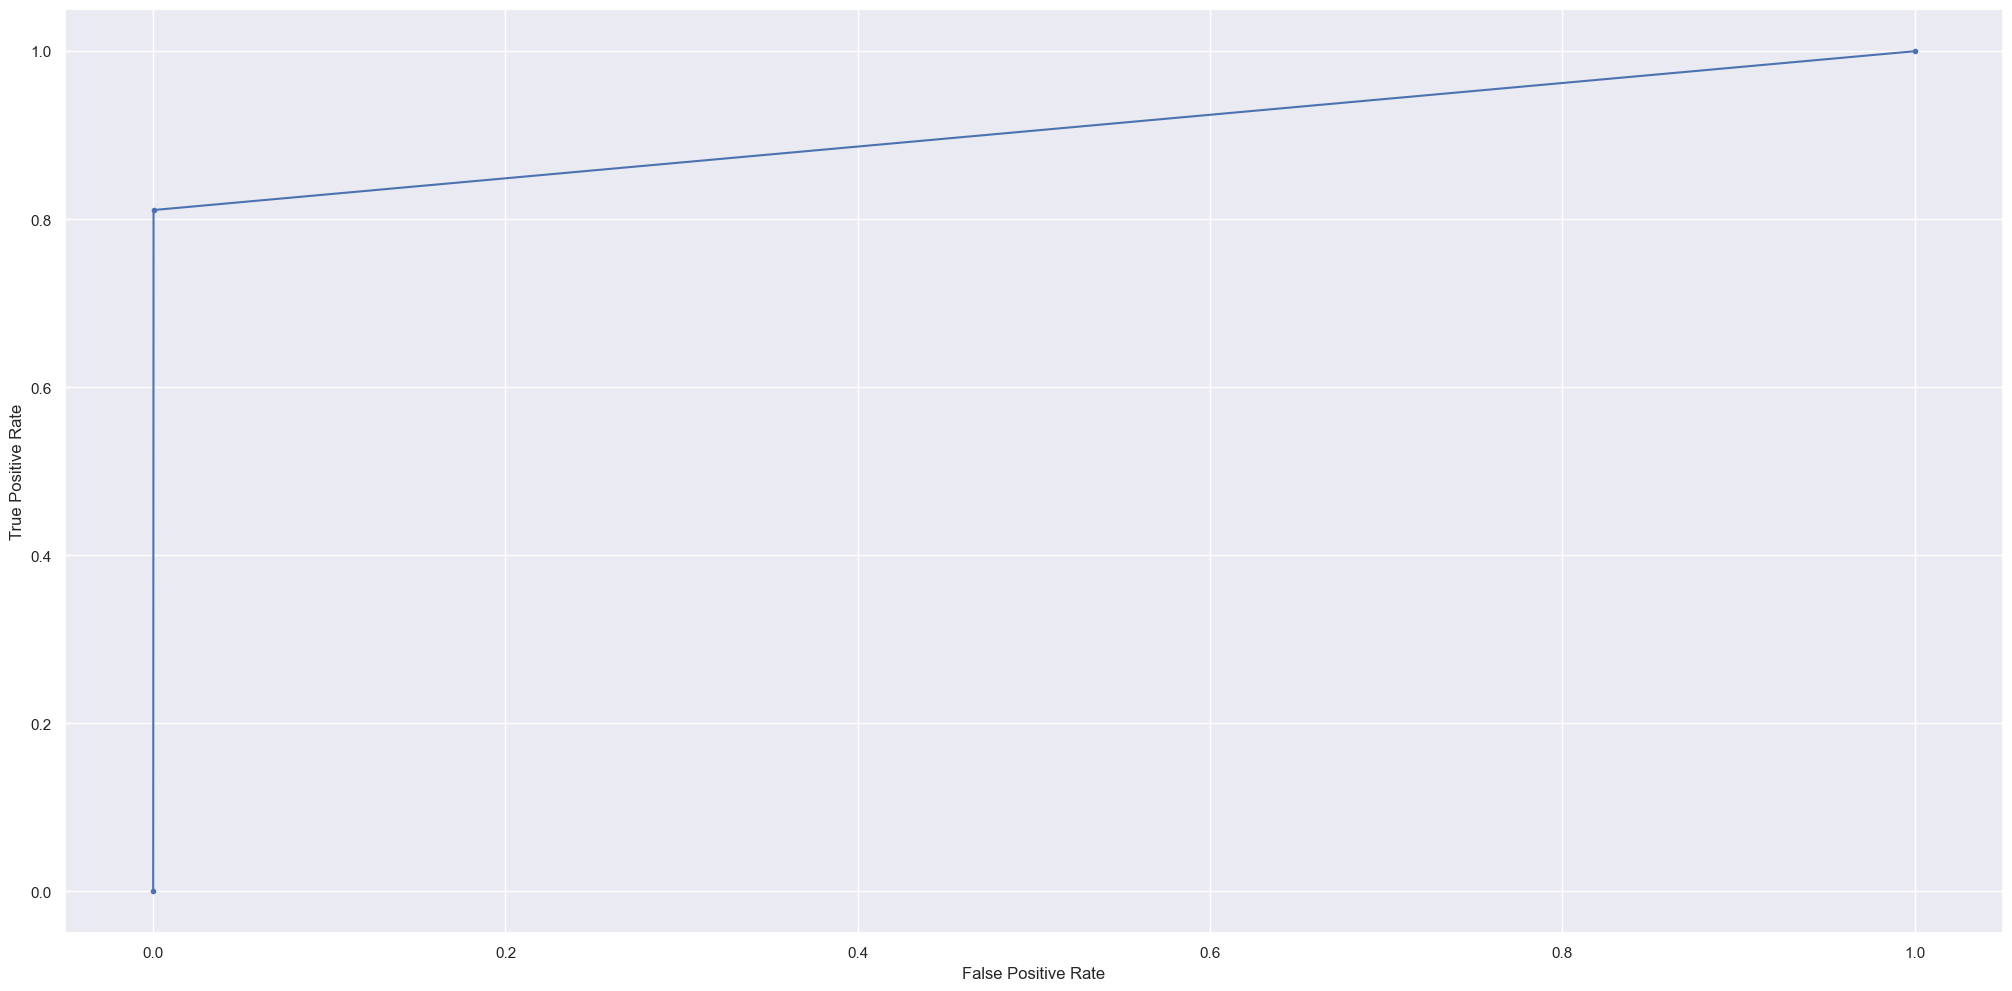

In [151]:
plt.plot (fpr, tpr, marker='.')
plt.xlabel ('False Positive Rate')
plt.ylabel ('True Positive Rate')

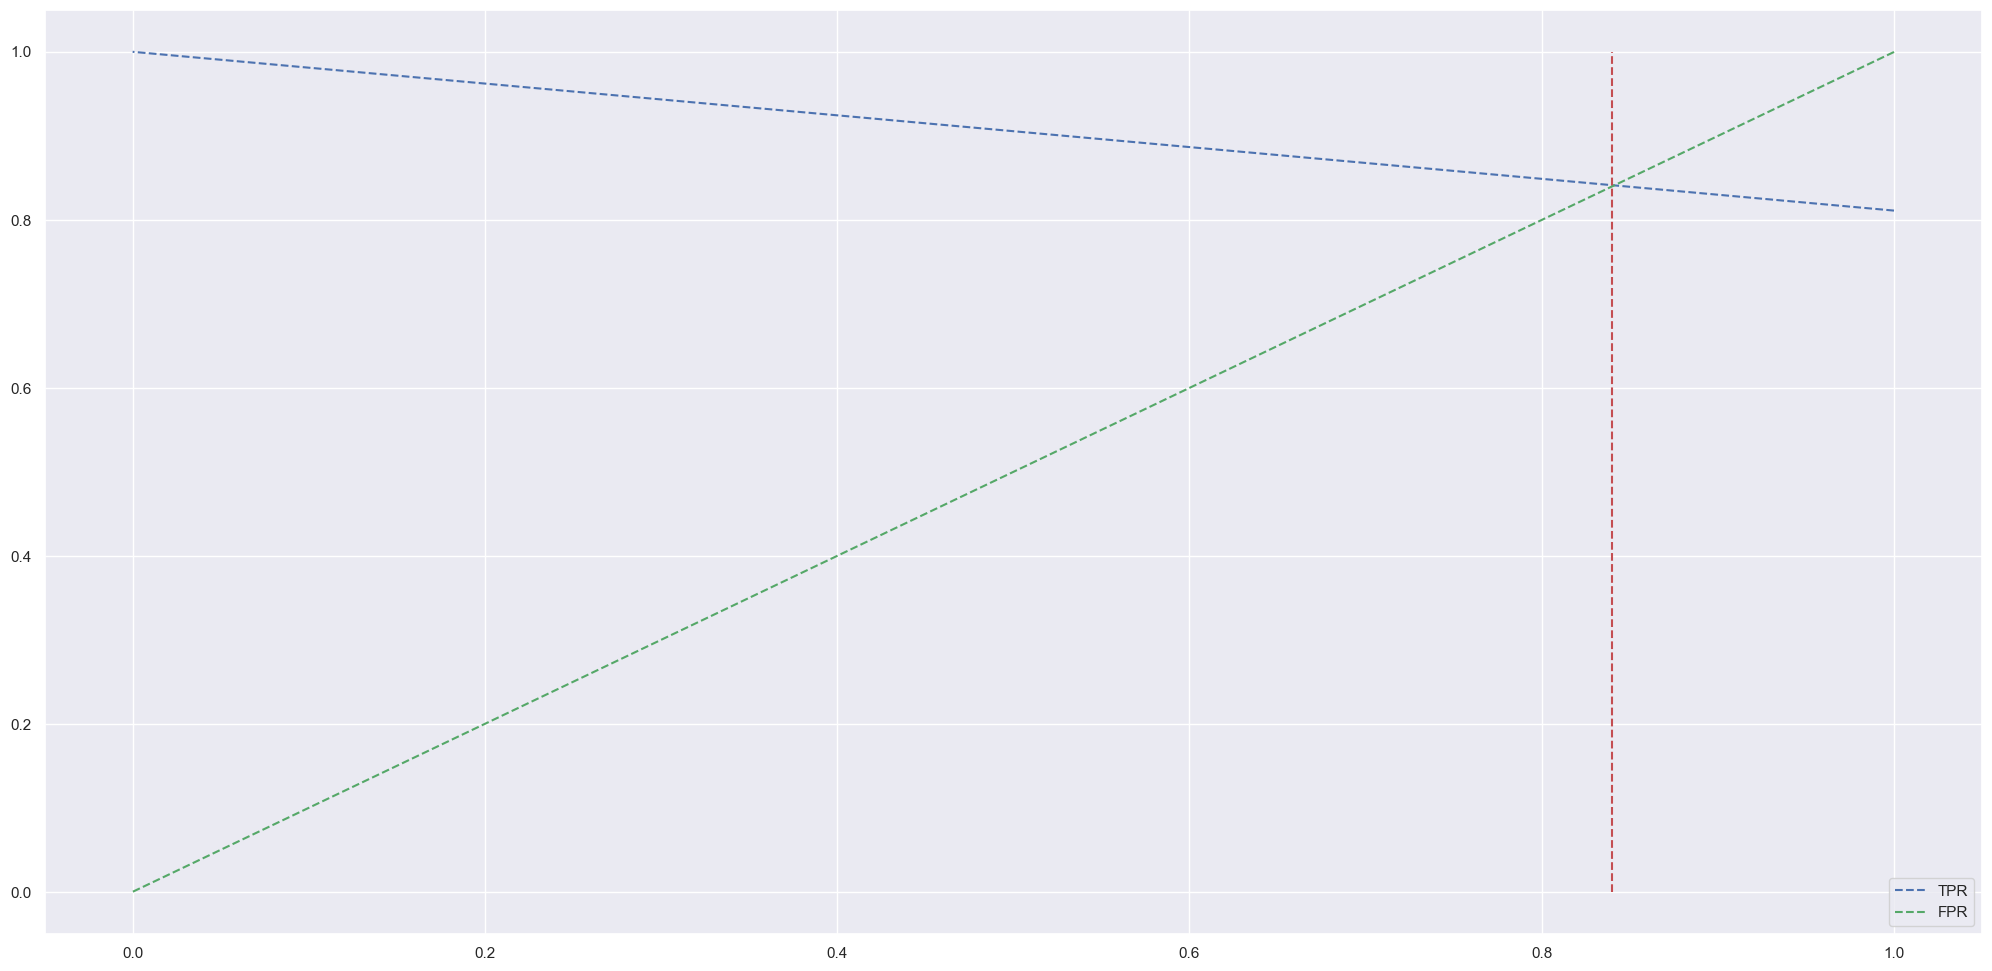

In [156]:
plt.plot (threshold, tpr, 'b--', label='TPR')
plt.plot (threshold, 1-fpr, 'g--', label='FPR')
plt.vlines( 0.84, 0, 1, color='r', linestyles='--')
plt.legend()

# 8.0 Hyperparameter Fine Tunnig

# 9.0 Final Model

# 10.0 Model Performance Results on Business

- Model performance and results report with respect to profit and loss. The following questions must be answared
    - What is the model's precision and accuracy?
    - What is the model's realibility with respect to transactions classificaton as legitimate or fraudulent?
    - What is the company forecasted revenue if the model classifies 100% of transactions?
    - What is the company forescasted loss in the casa of model failure?
    - What is the Blocker Fraud Company forecasted proft using the model?
    

## 10.1 Next Steps
- Model deployment
- CI/CD
- Unit Tests
- Model hyperparameters fine-tunning